In [2]:
import numpy as np
from scipy.stats import spearmanr


def mean_se(data):
    mean = np.mean(data)
    se = np.std(data) / np.sqrt(len(data))
    return mean, se

# Results processing script

In [447]:
import json
import os
import numpy as np
from scipy import stats

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"],
    "vaml": ["dynamics", "value_aware"],
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        
        # Explicitly handle None (JSON null)
        if val is None:
            return -np.inf
        
        # Attempt to convert to float (handles strings like "10.5")
        return float(val)
        
    except (KeyError, TypeError, ValueError):
        # KeyError: Key missing
        # TypeError: Trying to access [key] on a None object
        # ValueError: Found a string that isn't a number
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    # 1. Extract raw scores for every method for every policy
    scores = {m: [] for m in METRIC_PATHS.keys()}
    
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    # Convert to numpy arrays for easier handling
    for m in scores:
        scores[m] = np.array(scores[m])

    # 2. Determine True Best Value (Oracle)
    # Validate that we have at least one valid ground truth value
    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    # 3. Calculate Rankings and Regrets
    file_output = {
        "rankings": {},
        "regrets": {}
    }

    for method, values in scores.items():
        # If a method has all -inf (all null), argsort is arbitrary but won't crash.
        # [::-1] reverses it to descending (Best to Worst).
        ranking = np.argsort(values)[::-1]
        
        file_output["rankings"][method] = ranking.tolist()
        
        if method != "env_mc":
            # Identify which policy this method thinks is best
            selected_policy_idx = ranking[0]
            
            # If the method picked a policy that has a NULL env_mc (unlikely but possible),
            # treating it as a standard float calculation might fail if we didn't sanitize inputs.
            # But true_values is sanitized to -inf if missing.
            val_of_selected = true_values[selected_policy_idx]
            
            # Sanity check: If the true value of the selected policy is -inf (missing data),
            # the regret is infinite/undefined.
            if np.isinf(val_of_selected):
                # Regret is theoretically infinite if we picked a policy with no result
                # Here we default to a very large number or just 0.0 depending on preference.
                # Usually, we skip, but for stability, let's record nan.
                regret = np.nan 
            else:
                regret = true_optimal_val - val_of_selected
            
            file_output["regrets"][method] = float(regret)

    return file_output

def aggregate_results(seed_range, file_pattern="./test/ant_pipeline/resnet/summary_0.5_{}.json"):
    """
    Iterates over seeds, processes files, and aggregates results into lists.
    """
    
    # Data structures to hold aggregated lists
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    
    valid_seeds = []

    print(f"Processing seeds {seed_range}...")

    for seed in seed_range:
        filename = file_pattern.format(seed)
        
        if not os.path.exists(filename):
            # print(f"Warning: File {filename} not found. Skipping.")
            continue
            
        # Process the individual file
        single_res = process_single_seed(filename)
        
        # If processing failed (e.g. env_mc was null), skip aggregation for this seed
        if single_res is None:
            continue

        valid_seeds.append(seed)
        
        # Append to aggregates
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
            
        for method in agg_regrets.keys():
            val = single_res["regrets"][method]
            # Only append if it's not NaN, or decide how you want to handle NaN regrets
            # Here we append it, and np.nanmean can handle it later if needed
            agg_regrets[method].append(val)

    return agg_rankings, agg_regrets, valid_seeds

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # Define the range of seeds you want to process
    SEEDS = list(range(0, 5))
    
    # Run aggregation
    rankings, regrets, processed_seeds = aggregate_results(SEEDS)

    if not processed_seeds:
        print("No valid files processed.")
    else:
        print("\n" + "="*30)
        print(f"AGGREGATED RESULTS ({len(processed_seeds)} seeds)")
        print("="*30)

        # 1. Output True Rankings
        print("\n--- True Rankings (env_mc) [List of Lists] ---")
        # Print first 3 to avoid clutter if list is huge
        print(str(rankings['env_mc'][:3]) + " ... (showing first 3)")

        # 2. Output OPE Rankings
        print("\n--- OPE Rankings [List of Lists] ---")
        for method in ['supervised', 'q_estimate', 'kendall', 'hinge', 'listnet']:
            print(f"\nMethod: {method}")
            print(str(rankings[method][:3]) + " ...")

        # 3. Output OPE Regrets
        print("\n--- OPE Regrets [List of Floats] ---")
        for method in ['supervised', 'q_estimate', 'kendall', 'hinge', 'listnet']:
            # Use nanmean to safely calculate mean ignoring NaNs
            avg_regret = np.nanmean(regrets[method])
            
            # Count how many valid regrets we actually have
            valid_count = np.count_nonzero(~np.isnan(regrets[method]))
            
            print(f"\nMethod: {method}")
            # print(f"Values: {regrets[method]}")
            print(f"Average Regret: {avg_regret:.4f} (calculated over {valid_count} valid seeds)")

Processing seeds [0, 1, 2, 3, 4]...

AGGREGATED RESULTS (5 seeds)

--- True Rankings (env_mc) [List of Lists] ---
[[5, 4, 3, 1, 2, 0], [5, 4, 3, 1, 2, 0], [5, 4, 3, 1, 2, 0]] ... (showing first 3)

--- OPE Rankings [List of Lists] ---

Method: supervised
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: q_estimate
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: kendall
[[5, 4, 3, 1, 2, 0], [5, 4, 0, 1, 2, 3], [1, 4, 5, 3, 2, 0]] ...

Method: hinge
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: listnet
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

--- OPE Regrets [List of Floats] ---

Method: supervised
Average Regret: 0.0000 (calculated over 5 valid seeds)

Method: q_estimate
Average Regret: 0.0000 (calculated over 5 valid seeds)

Method: kendall
Average Regret: 3.4954 (calculated over 5 valid seeds)

Method: hinge
Average Regret: 0.0000 (calculated over 5 valid seeds)

Method: listnet
Aver

In [448]:
def analyze_performance(rankings, regrets):
    """
    Calculates Average Regret (+- SE), Spearman's Correlation (+- SE),
    and Pass@1 (+- SE).
    
    Args:
        rankings (dict): Dictionary of lists of lists.
        regrets (dict): Dictionary of lists of floats.
    """
    
    # Helper to calculate Mean and Standard Error
    def get_stats(data):
        if not data:
            return 0.0, 0.0
        data = np.array(data)
        mean = np.mean(data)
        # ddof=1 for sample standard deviation
        se = np.std(data, ddof=1) / np.sqrt(len(data)) 
        return mean, se

    # Helper to convert "sorted indices" into a "rank vector"
    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        rank_vec = np.zeros(n)
        for rank, policy_idx in enumerate(sorted_indices):
            rank_vec[policy_idx] = rank
        return rank_vec

    # Adjusted column widths for the new metric
    print(f"{'METHOD':<15} | {'AVG REGRET':<18} | {'AVG SPEARMAN':<18} | {'PASS@1 (%)':<18}")
    print("-" * 75)

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    
    for method in methods:
        method_rankings = rankings[method]
        
        # 1. Regret Statistics
        method_regrets = regrets[method]
        reg_mean, reg_se = get_stats(method_regrets)
        
        # 2. Spearman & Pass@1 Statistics
        spearman_scores = []
        pass1_scores = []
        
        for true_sort, method_sort in zip(true_rankings, method_rankings):
            # --- Spearman Calculation ---
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            
            # --- Pass@1 Calculation ---
            # Compare the first element (index 0) of both sorted lists
            # 1.0 if they identify the same best policy, 0.0 otherwise
            is_match = 1.0 if true_sort[0] == method_sort[0] else 0.0
            pass1_scores.append(is_match)
        print(spearman_scores)
        corr_mean, corr_se = get_stats(spearman_scores)
        p1_mean, p1_se = get_stats(pass1_scores)
        
        # Convert Pass@1 to percentage
        p1_mean_pct = p1_mean * 100
        p1_se_pct = p1_se * 100
        
        # 3. Print Row
        reg_str = f"{reg_mean:.2f} ± {reg_se:.2f}"
        corr_str = f"{corr_mean:.3f} ± {corr_se:.3f}"
        p1_str = f"{p1_mean_pct:.1f}% ± {p1_se_pct:.1f}%"
        
        print(f"{method:<15} | {reg_str:<18} | {corr_str:<18} | {p1_str:<18}")

# ==========================================
# EXAMPLE USAGE
# ==========================================
if __name__ == "__main__":
    # Assuming 'rankings' and 'regrets' are already computed 
    # via the aggregate_results function from the previous script
    
    print("\n" + "="*30)
    print("STATISTICAL ANALYSIS")
    print("="*30)
    
    analyze_performance(rankings, regrets)


STATISTICAL ANALYSIS
METHOD          | AVG REGRET         | AVG SPEARMAN       | PASS@1 (%)        
---------------------------------------------------------------------------
[0.942857142857143, 0.942857142857143, 0.942857142857143, 0.942857142857143, 0.942857142857143]
q_estimate      | 0.00 ± 0.00        | 0.943 ± 0.000      | 100.0% ± 0.0%     
[0.942857142857143, 0.942857142857143, 0.942857142857143, 0.942857142857143, 0.942857142857143]
supervised      | 0.00 ± 0.00        | 0.943 ± 0.000      | 100.0% ± 0.0%     
[1.0, 0.48571428571428577, 0.6, 0.7714285714285715, 0.14285714285714288]
kendall         | 3.50 ± 1.68        | 0.600 ± 0.143      | 40.0% ± 24.5%     
[0.942857142857143, 0.942857142857143, 0.942857142857143, 0.942857142857143, 0.942857142857143]
hinge           | 0.00 ± 0.00        | 0.943 ± 0.000      | 100.0% ± 0.0%     
[0.942857142857143, 0.942857142857143, 0.942857142857143, 0.942857142857143, 0.942857142857143]
listnet         | 0.00 ± 0.00        | 0.943 ± 0.0

/tmp/ipykernel_605004/1830847979.py:28: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


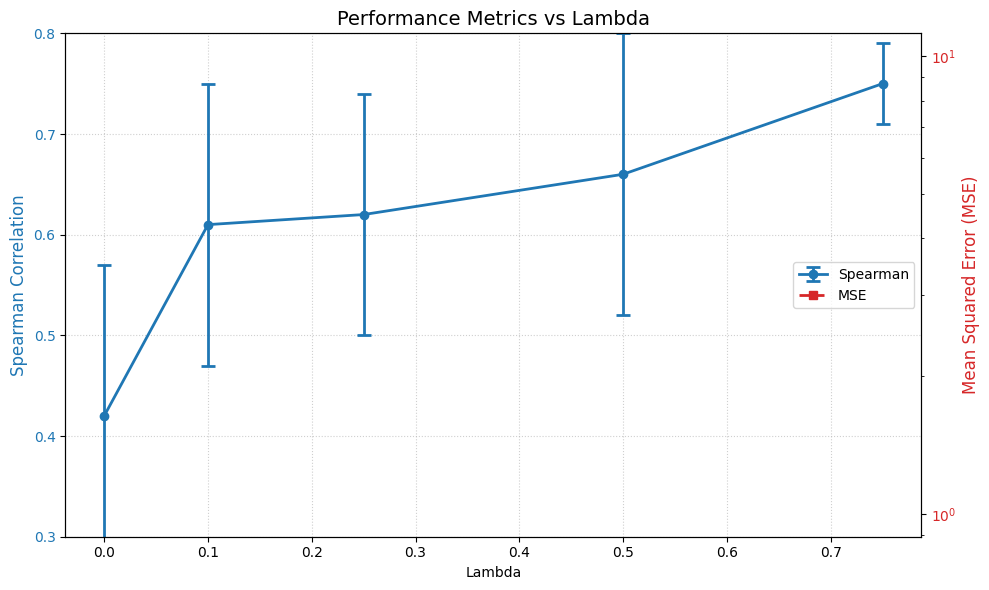

In [442]:
import matplotlib.pyplot as plt
import numpy as np

#pendulum

lambdas = [0, 0.1, 0.25, 0.5, 0.75]
spearman = [0.42, 0.61, 0.62, 0.66, 0.75]
spearman_ses = [0.15,0.14,0.12,0.14, 0.04]
mse = [0,0,0,0,0]

fig, ax1 = plt.subplots(figsize=(10, 6))

# 3. Plot Spearman on the Left Axis (ax1)
color_spearman = 'tab:blue'
ax1.set_xlabel('Lambda')
ax1.set_ylabel('Spearman Correlation', color=color_spearman, fontsize=12)
ax1.errorbar(lambdas, spearman, yerr=spearman_ses, color=color_spearman, marker='o', linestyle='-', linewidth=2, label='Spearman', capsize=5, capthick=2)
ax1.tick_params(axis='y', labelcolor=color_spearman)
ax1.set_ylim(0.3, 0.8) # Setting a reasonable range for correlation

# 4. Plot MSE on the Right Axis (ax2)
ax2 = ax1.twinx() 
color_mse = 'tab:red'
ax2.set_ylabel('Mean Squared Error (MSE)', color=color_mse, fontsize=12)
ax2.plot(lambdas, mse, color=color_mse, marker='s', linestyle='--', linewidth=2, label='MSE')
ax2.tick_params(axis='y', labelcolor=color_mse)

ax2.set_yscale('log') 

ax1.grid(True, linestyle=':', alpha=0.6)
plt.title('Performance Metrics vs Lambda', fontsize=14)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.tight_layout()
plt.show()

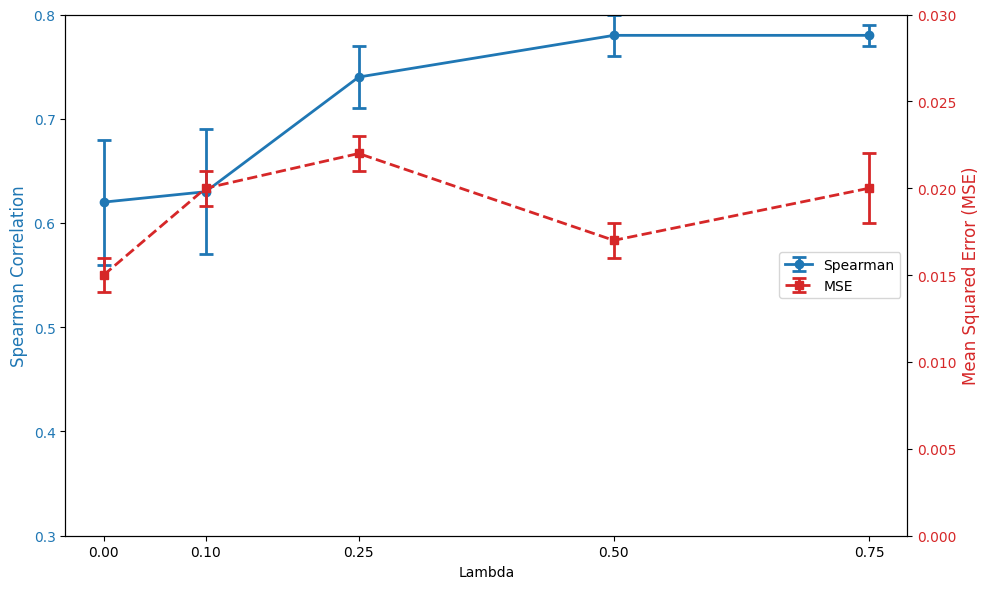

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#hopper
lambdas = [0, 0.1, 0.25, 0.5, 0.75]
spearman = [0.62, 0.63, 0.74, 0.78, 0.78]
spearman_ses = [0.06, 0.06,0.03, 0.02,0.01]
regret = [0.68, 0.68, 0.39, 0.14, 0]
regret_ses = [0.12, 0.16, 0.27, 0.14, 0]
mse = [0.015, 0.020, 0.022, 0.017, 0.020]
mse_ses = [0.001, 0.001, 0.001, 0.001, 0.002]

# 2. Setup the plot structure
fig, ax1 = plt.subplots(figsize=(10, 6))

# 3. Plot Spearman on the Left Axis (ax1)
color_spearman = 'tab:blue'
ax1.set_xlabel('Lambda')
ax1.set_ylabel('Spearman Correlation', color=color_spearman, fontsize=12)
ax1.errorbar(lambdas, spearman, yerr=spearman_ses, color=color_spearman, marker='o', linestyle='-', linewidth=2, label='Spearman', capsize=5, capthick=2)
ax1.tick_params(axis='y', labelcolor=color_spearman)
ax1.set_ylim(0.3, 0.8) # Setting a reasonable range for correlation

ax1.set_xticks(lambdas)

# 4. Plot MSE on the Right Axis (ax2)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color_mse = 'tab:red'
ax2.set_ylabel('Mean Squared Error (MSE)', color=color_mse, fontsize=12)
ax2.errorbar(lambdas, mse, yerr=mse_ses, color=color_mse, marker='s', linestyle='--', linewidth=2, label='MSE', capsize=5, capthick=2)
ax2.tick_params(axis='y', labelcolor=color_mse)
ax2.set_ylim(0, 0.03)

# 7. Combine Legends
# We have to gather handles from both axes to make one unified legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.tight_layout()
plt.show()

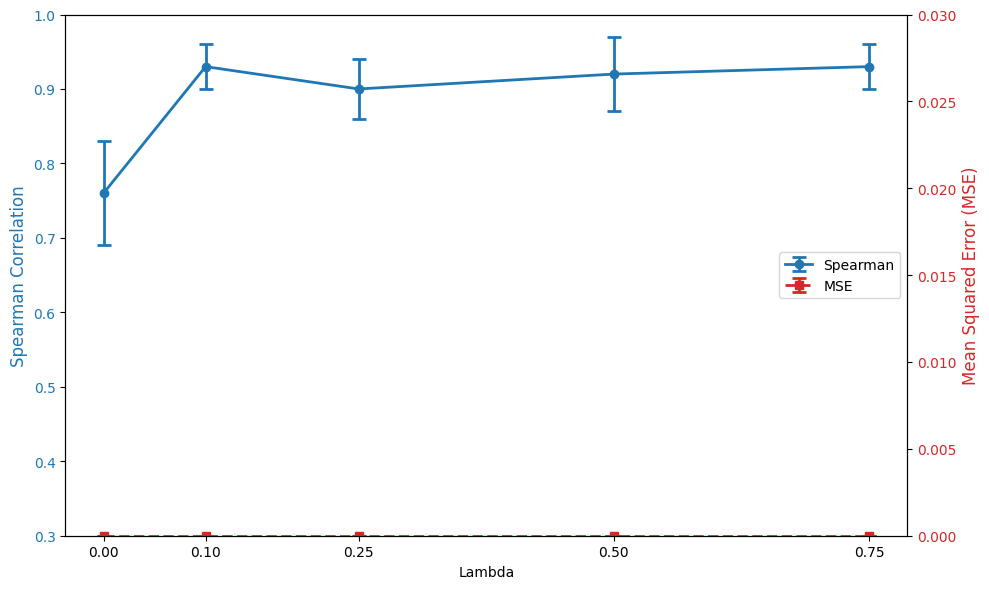

In [ ]:
#lunarlander
lambdas = [0, 0.1, 0.25, 0.5, 0.75]
spearman = [0.76, 0.93, 0.90, 0.92, 0.93]
spearman_ses = [0.07, 0.03,0.04, 0.05,0.03]
mse = [0,0,0,0,0]
mse_ses = [0,0,0,0,0]

# 2. Setup the plot structure
fig, ax1 = plt.subplots(figsize=(10, 6))

# 3. Plot Spearman on the Left Axis (ax1)
color_spearman = 'tab:blue'
ax1.set_xlabel('Lambda')
ax1.set_ylabel('Spearman Correlation', color=color_spearman, fontsize=12)
ax1.errorbar(lambdas, spearman, yerr=spearman_ses, color=color_spearman, marker='o', linestyle='-', linewidth=2, label='Spearman', capsize=5, capthick=2)
ax1.tick_params(axis='y', labelcolor=color_spearman)
ax1.set_ylim(0.3, 1) # Setting a reasonable range for correlation

ax1.set_xticks(lambdas)

# 4. Plot MSE on the Right Axis (ax2)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color_mse = 'tab:red'
ax2.set_ylabel('Mean Squared Error (MSE)', color=color_mse, fontsize=12)
ax2.errorbar(lambdas, mse, yerr=mse_ses, color=color_mse, marker='s', linestyle='--', linewidth=2, label='MSE', capsize=5, capthick=2)
ax2.tick_params(axis='y', labelcolor=color_mse)
ax2.set_ylim(0, 0.03)

# 7. Combine Legends
# We have to gather handles from both axes to make one unified legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.tight_layout()
plt.show()

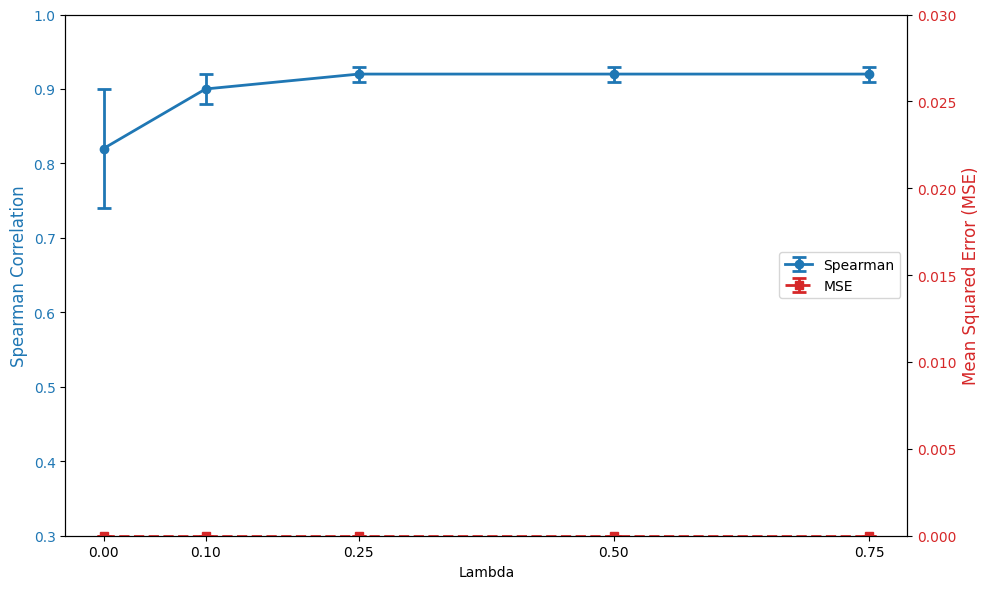

In [ ]:
#walker
lambdas = [0, 0.1, 0.25, 0.5, 0.75]
spearman = [0.82, 0.90, 0.92, 0.92, 0.92]
spearman_ses = [0.08, 0.02,0.01, 0.01,0.01]
mse = [0,0,0,0,0]
mse_ses = [0,0,0,0,0]

# 2. Setup the plot structure
fig, ax1 = plt.subplots(figsize=(10, 6))

# 3. Plot Spearman on the Left Axis (ax1)
color_spearman = 'tab:blue'
ax1.set_xlabel('Lambda')
ax1.set_ylabel('Spearman Correlation', color=color_spearman, fontsize=12)
ax1.errorbar(lambdas, spearman, yerr=spearman_ses, color=color_spearman, marker='o', linestyle='-', linewidth=2, label='Spearman', capsize=5, capthick=2)
ax1.tick_params(axis='y', labelcolor=color_spearman)
ax1.set_ylim(0.3, 1) # Setting a reasonable range for correlation

ax1.set_xticks(lambdas)

# 4. Plot MSE on the Right Axis (ax2)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color_mse = 'tab:red'
ax2.set_ylabel('Mean Squared Error (MSE)', color=color_mse, fontsize=12)
ax2.errorbar(lambdas, mse, yerr=mse_ses, color=color_mse, marker='s', linestyle='--', linewidth=2, label='MSE', capsize=5, capthick=2)
ax2.tick_params(axis='y', labelcolor=color_mse)
ax2.set_ylim(0, 0.03)

# 7. Combine Legends
# We have to gather handles from both axes to make one unified legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.tight_layout()
plt.show()

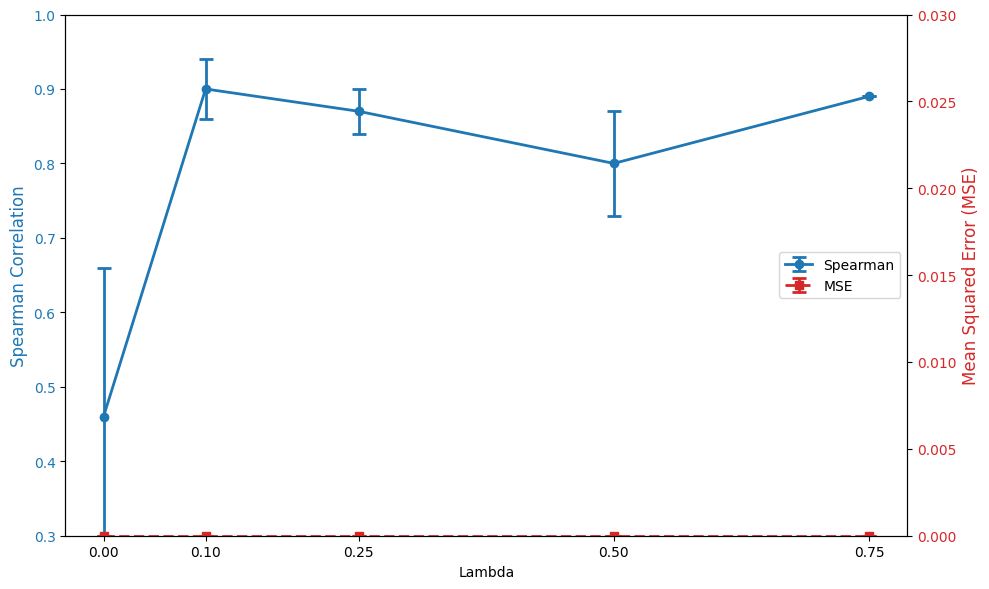

In [ ]:
#cheetah
lambdas = [0, 0.1, 0.25, 0.5, 0.75]
spearman = [0.46, 0.90, 0.87, 0.80, 0.89]
spearman_ses = [0.2, 0.04, 0.03, 0.07,0.00]
mse = [0,0,0,0,0]
mse_ses = [0,0,0,0,0]

# 2. Setup the plot structure
fig, ax1 = plt.subplots(figsize=(10, 6))

# 3. Plot Spearman on the Left Axis (ax1)
color_spearman = 'tab:blue'
ax1.set_xlabel('Lambda')
ax1.set_ylabel('Spearman Correlation', color=color_spearman, fontsize=12)
ax1.errorbar(lambdas, spearman, yerr=spearman_ses, color=color_spearman, marker='o', linestyle='-', linewidth=2, label='Spearman', capsize=5, capthick=2)
ax1.tick_params(axis='y', labelcolor=color_spearman)
ax1.set_ylim(0.3, 1) # Setting a reasonable range for correlation

ax1.set_xticks(lambdas)

# 4. Plot MSE on the Right Axis (ax2)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color_mse = 'tab:red'
ax2.set_ylabel('Mean Squared Error (MSE)', color=color_mse, fontsize=12)
ax2.errorbar(lambdas, mse, yerr=mse_ses, color=color_mse, marker='s', linestyle='--', linewidth=2, label='MSE', capsize=5, capthick=2)
ax2.tick_params(axis='y', labelcolor=color_mse)
ax2.set_ylim(0, 0.03)

# 7. Combine Legends
# We have to gather handles from both axes to make one unified legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.tight_layout()
plt.show()

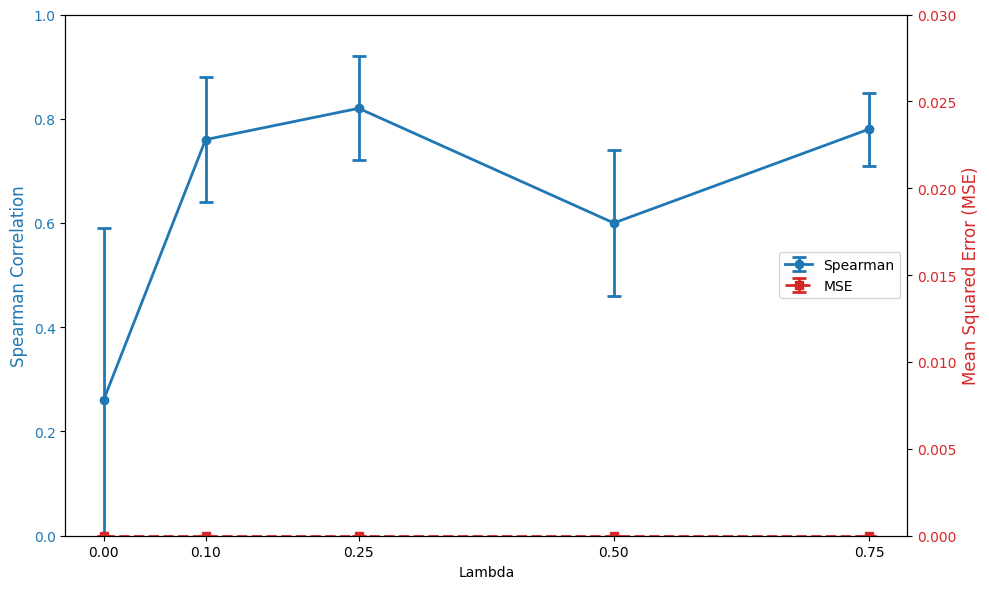

In [449]:
#ant
lambdas = [0, 0.1, 0.25, 0.5, 0.75]
spearman = [0.26, 0.76, 0.82, 0.6, 0.78]
spearman_ses = [0.33, 0.12, 0.10, 0.14, 0.07]
mse = [0,0,0,0,0]
mse_ses = [0,0,0,0,0]

# 2. Setup the plot structure
fig, ax1 = plt.subplots(figsize=(10, 6))

# 3. Plot Spearman on the Left Axis (ax1)
color_spearman = 'tab:blue'
ax1.set_xlabel('Lambda')
ax1.set_ylabel('Spearman Correlation', color=color_spearman, fontsize=12)
ax1.errorbar(lambdas, spearman, yerr=spearman_ses, color=color_spearman, marker='o', linestyle='-', linewidth=2, label='Spearman', capsize=5, capthick=2)
ax1.tick_params(axis='y', labelcolor=color_spearman)
ax1.set_ylim(0, 1) # Setting a reasonable range for correlation

ax1.set_xticks(lambdas)

# 4. Plot MSE on the Right Axis (ax2)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color_mse = 'tab:red'
ax2.set_ylabel('Mean Squared Error (MSE)', color=color_mse, fontsize=12)
ax2.errorbar(lambdas, mse, yerr=mse_ses, color=color_mse, marker='s', linestyle='--', linewidth=2, label='MSE', capsize=5, capthick=2)
ax2.tick_params(axis='y', labelcolor=color_mse)
ax2.set_ylim(0, 0.03)

# 7. Combine Legends
# We have to gather handles from both axes to make one unified legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.tight_layout()
plt.show()

In [1]:
#graphing pane
import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats

# ============== CONFIGURATION ==============
PIPELINE = "pendulum_pipeline"  # Change this to switch pipelines (e.g., "lunarlander_pipeline", "cancer_pipeline")
SEEDS = list(range(0, 30))
# ===========================================

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

# VaGraM metric path for VAML files
VAGRAM_METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "VaGraM": ["dynamics", "value_aware"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def process_single_seed_vagram(file_path):
    """Parses a single VAML JSON file and calculates rankings and regrets for VaGraM."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in VAGRAM_METRIC_PATHS.keys()}
    for entry in results:
        for method, path in VAGRAM_METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results(seed_range, folder, pipeline=PIPELINE):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./test/{pipeline}/{folder}/summary_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
    return agg_rankings, agg_regrets, valid_seeds

def aggregate_results_vagram(seed_range, pipeline=PIPELINE):
    """Iterates over seeds for resnet folder, processes VAML files, and aggregates VaGraM results."""
    pattern = f"./test/{pipeline}/mlp/summary_VAML_{{}}.json"
    agg_rankings = {m: [] for m in VAGRAM_METRIC_PATHS.keys()}
    agg_regrets = {"VaGraM": []}
    valid_seeds = []
    print(f"Processing VaGraM (VAML) seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed_vagram(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        agg_regrets["VaGraM"].append(single_res["regrets"]["VaGraM"])
    return agg_rankings, agg_regrets, valid_seeds

def collect_performance_bca(rankings, regrets, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    methods = ["supervised", "kendall"]
    for method in methods:
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

def collect_performance_bca_vagram(rankings, regrets, n_boot=10000):
    """Collect BCA stats for VaGraM method."""
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    method = "VaGraM"
    
    if method not in regrets or len(regrets[method]) == 0:
        return results
    
    reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
    spearman_scores = []
    pass1_scores = []
    for true_sort, method_sort in zip(true_rankings, rankings[method]):
        r_true = to_rank_vector(true_sort)
        r_method = to_rank_vector(method_sort)
        corr, _ = stats.spearmanr(r_true, r_method)
        spearman_scores.append(corr)
        pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
    corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
    p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
    results[method] = {
        "regret": (reg_mean, reg_ci),
        "spearman": (corr_mean, corr_ci),
        "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
    }
    return results

# Compute and plot for each model folder

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

def plot_benchmarks(pipeline = PIPELINE, seeds = SEEDS, ylim = 1.5, save=False):
    MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
    metrics = [("regret", r"$\mathrm{Regret}$"), ("spearman", r"$\mathrm{Spearman}$")]

    results_by_folder = {}
    for folder in MODEL_FOLDERS:
        rankings, regrets, processed_seeds = aggregate_results(seeds, folder, pipeline)
        if not processed_seeds:
            print(f"No valid seeds for {folder}; skipping.")
            continue
        results_by_folder[folder] = collect_performance_bca(rankings, regrets)

    # Aggregate VaGraM results from resnet/summary_VAML_* files
    vagram_rankings, vagram_regrets, vagram_seeds = aggregate_results_vagram(seeds, pipeline)
    vagram_results = collect_performance_bca_vagram(vagram_rankings, vagram_regrets)

    methods = ["supervised", "kendall"]  # Methods per architecture group
    folders = list(results_by_folder.keys())

    # Helper to map folder names to Capitalized + TeX versions
    def format_folder_name(name):
        # Just simple capitalization or specific overrides if needed
        if name.lower() == "gru":
            return r"$\mathrm{GRU}$"
        if name.lower() == "mlp":
            return r"$\mathrm{MLP}$"
        if name.lower() == "ode":
            return r"$\mathrm{NODE}$"
        # For others like Transformer, ResNet, just Title case
        formatted = name.replace("resnet", "ResNet").capitalize()
        if name.lower() == "resnet": formatted = "ResNet"
        return rf"$\mathrm{{{formatted}}}$"

    if not folders:
        print("No results to plot.")
    else:
        group_gap = 0.6
        group_size = len(methods)  # 2 bars per architecture group
        
        # Positions for architecture groups
        positions = []
        for i, folder in enumerate(folders):
            base = i * (group_size + group_gap)
            for j in range(group_size):
                positions.append(base + j)
        centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
        
        # Position for VaGraM bar (rightmost, with extra gap)
        vagram_gap = 1.2  # Extra gap before VaGraM
        vagram_position = positions[-1] + vagram_gap + 1
        
        palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA7"]
        folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
        hatch_map = {"supervised": "//", "kendall": None}
        
        face_colors = []
        edge_colors = []
        hatches = []
        for folder in folders:
            base_color = folder_colors[folder]
            for m in methods:
                if m == "supervised":
                    face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                    edge_colors.append(base_color)
                    hatches.append(hatch_map[m])
                else:
                    face_colors.append(base_color)
                    edge_colors.append(base_color)
                    hatches.append(hatch_map[m])

        fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(max(8, 2 * len(folders) + 2), 8), sharex=True)
        # Format pipeline name for title (e.g., "pendulum_pipeline" -> "Pendulum")
        plot_title = pipeline.replace("_pipeline", "").replace("_", " ").title()
        axes[0].set_title(plot_title, fontsize=32)

        for ax, (metric, label) in zip(axes, metrics):
            means = []
            lowers = []
            uppers = []
            # Architecture group bars
            for folder in folders:
                res = results_by_folder[folder]
                for m in methods:
                    if m not in res:
                        means.append(np.nan)
                        lowers.append(np.nan)
                        uppers.append(np.nan)
                        continue
                    mean, ci = res[m][metric]
                    means.append(mean)
                    lowers.append(mean - ci[0])
                    uppers.append(ci[1] - mean)
            
            # Plot architecture bars
            for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
                ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1, rasterized=True)
            
            # Plot VaGraM bar (grey, standalone)
            if "VaGraM" in vagram_results:
                vagram_mean, vagram_ci = vagram_results["VaGraM"][metric]
                vagram_lo = vagram_mean - vagram_ci[0]
                vagram_up = vagram_ci[1] - vagram_mean
                ax.bar(vagram_position, vagram_mean, yerr=[[vagram_lo], [vagram_up]], capsize=5, 
                    color="grey", edgecolor="dimgrey", linewidth=1, rasterized=True)
            
            ax.set_ylabel(label, fontsize=28)
            ax.grid(axis="y", linestyle="--", alpha=0.3)
            ax.tick_params(axis='y', labelsize=20)
            if metric == "regret":
                ax.set_ylim(0, ylim)

        # Level 1 tick labels: DT (supervised) / DT^2 (kendall) for architecture groups, VaGraM for baseline
        bar_labels = []
        for _ in folders:
            bar_labels.extend([r"$\mathrm{DT}$", r"$\mathrm{DT}^2$"])
        bar_labels.append(r"$\mathrm{VaGraM}$")
        
        all_positions = positions + [vagram_position]
        axes[-1].set_xticks(all_positions)
        axes[-1].set_xticklabels(bar_labels, rotation=0, ha="center", fontsize=24)

        # Level 2 labels: architecture names below the axis
        trans = axes[-1].get_xaxis_transform()
        for center, folder in zip(centers, folders):
            display_name = format_folder_name(folder)
            axes[-1].text(center, -0.14, display_name, transform=trans, ha="center", va="top", fontsize=28)

        folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=format_folder_name(f)) for f in folders]
        method_handles = [
            Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
            Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
            Patch(facecolor="grey", edgecolor="dimgrey", label="VaGraM", linewidth=1),
        ]
        
        fig.tight_layout()
        if save:
            plt.savefig(f'plots/{pipeline}.pdf')

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


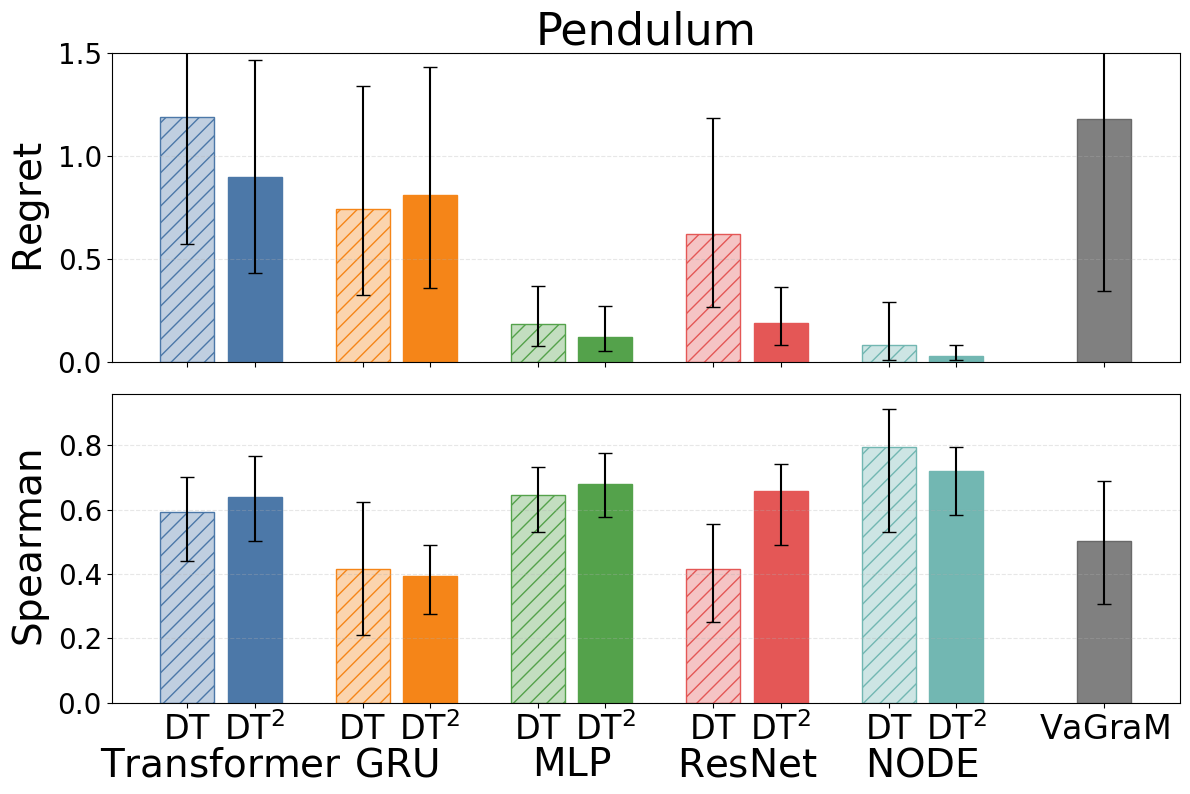

In [3]:
plot_benchmarks(pipeline = 'pendulum_pipeline', seeds = list(range(0,10)), ylim = 1.5, save = True)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


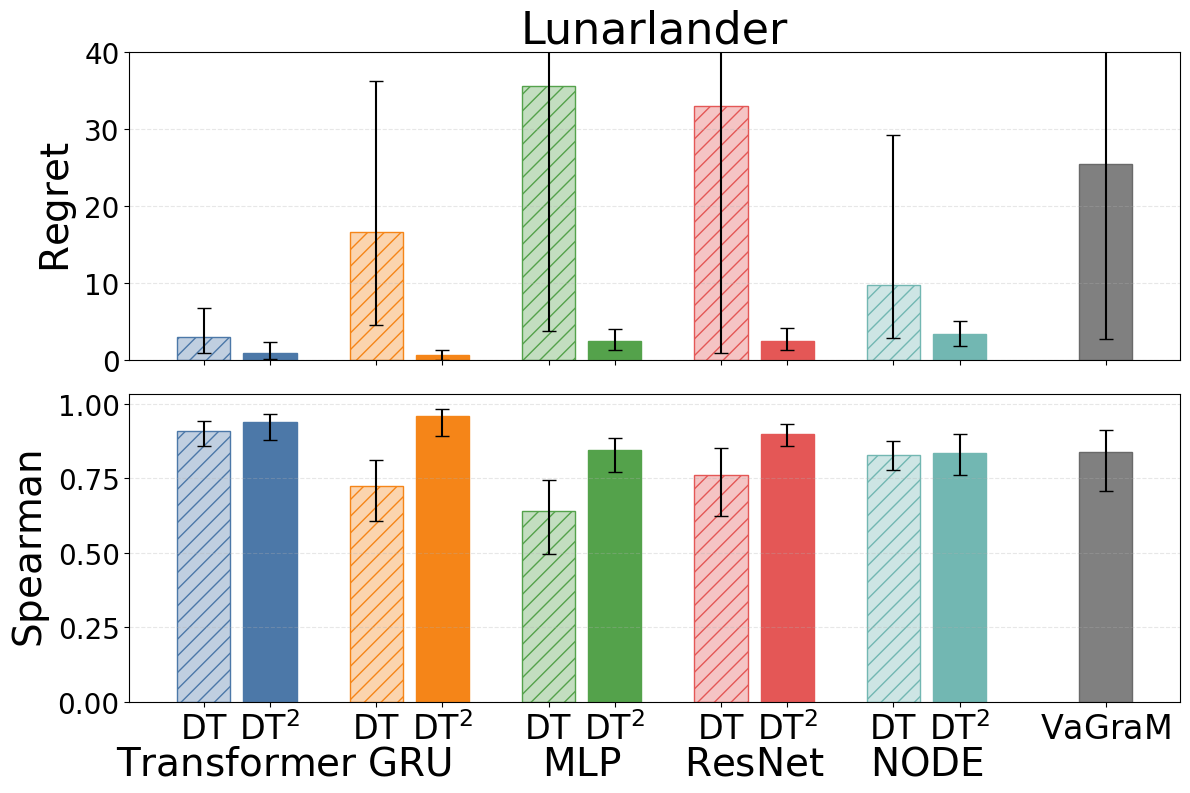

In [7]:
plot_benchmarks(pipeline = 'lunarlander_pipeline', seeds = list(range(0,30)), ylim = 40, save = True)

Processing transformer seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


Processing gru seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing mlp seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing resnet seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing ode seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing VaGraM (VAML) seeds [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


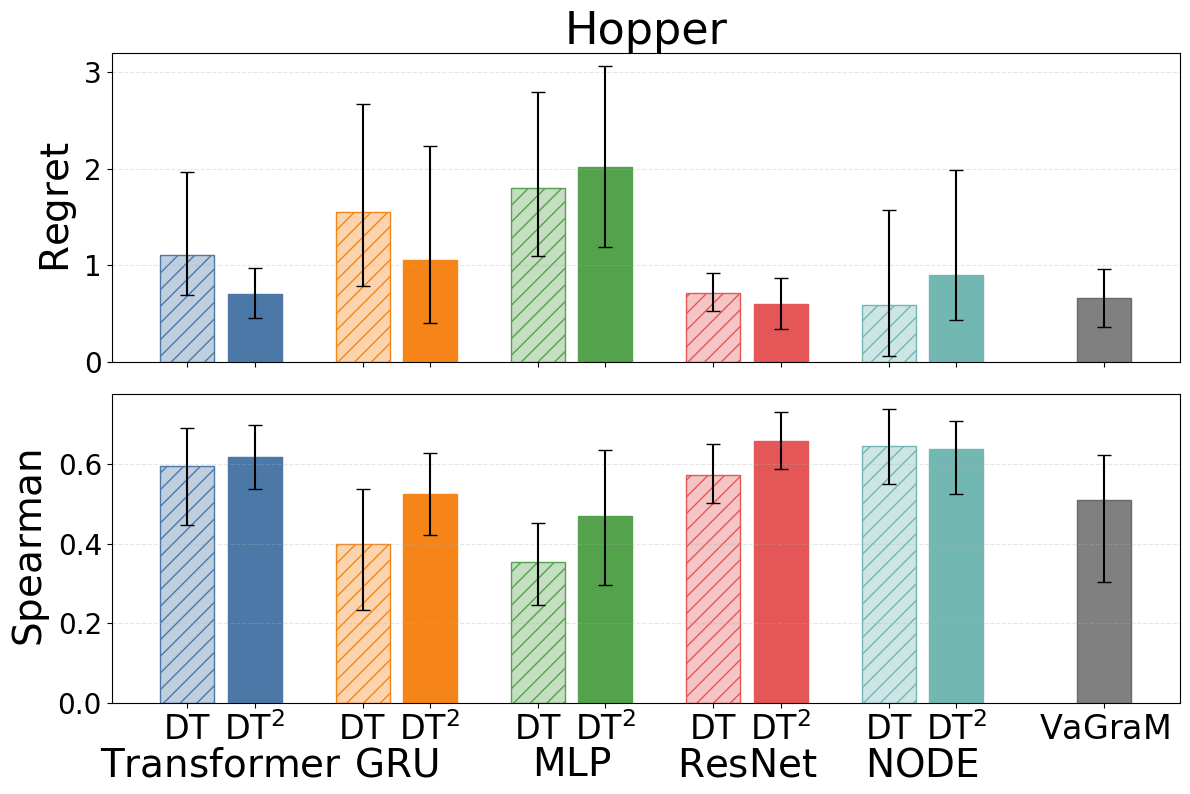

In [10]:
plot_benchmarks(pipeline = 'hopper_pipeline', seeds = list(range(2,30)), ylim = 3.2, save = True)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


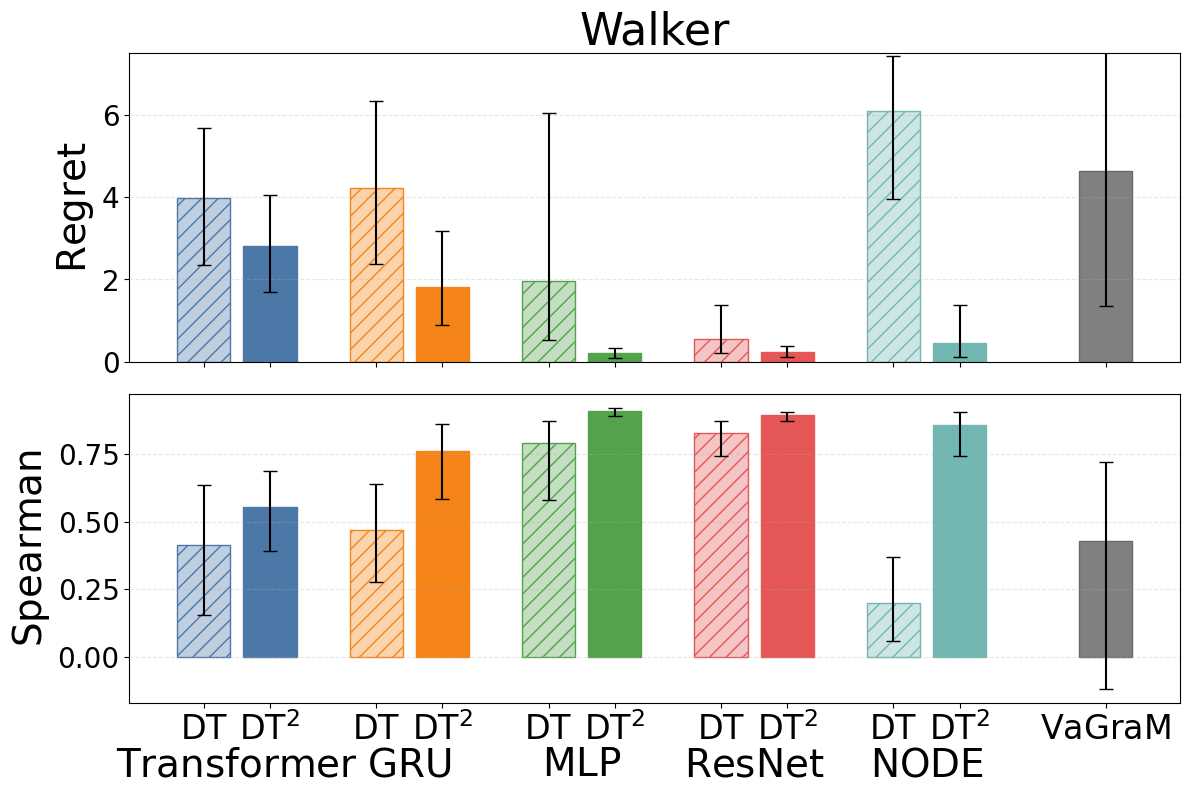

In [11]:
plot_benchmarks(pipeline = 'walker_pipeline', seeds = list(range(0,30)), ylim = 7.5, save = True)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


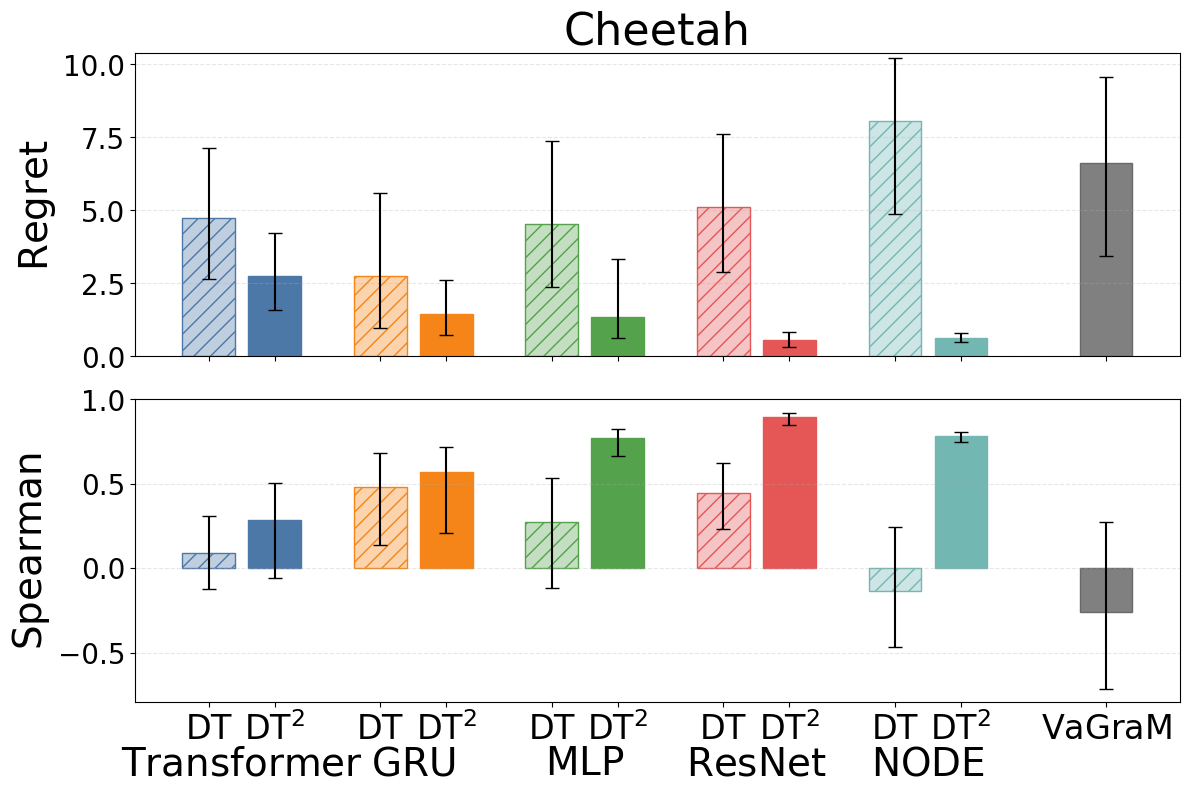

In [12]:
plot_benchmarks(pipeline = 'cheetah_pipeline', seeds = list(range(0, 30)), ylim = 10.4, save = True)

Processing transformer seeds [0, 1, 2, 3, 4]...


Processing gru seeds [0, 1, 2, 3, 4]...
Processing mlp seeds [0, 1, 2, 3, 4]...
Processing resnet seeds [0, 1, 2, 3, 4]...
Processing ode seeds [0, 1, 2, 3, 4]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4]...


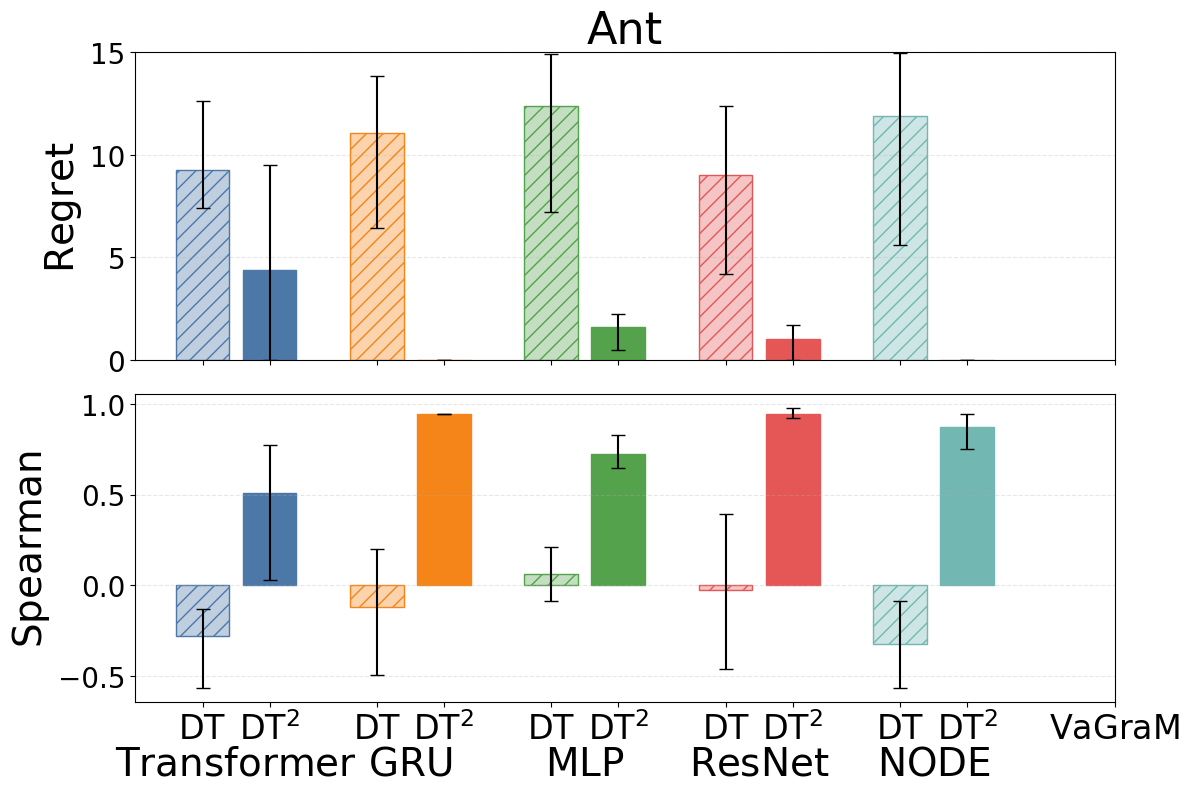

In [34]:
plot_benchmarks(pipeline = 'ant_pipeline', seeds = list(range(0, 5)), ylim = 15, save = False) #lambda 0.99, rollout len 50

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


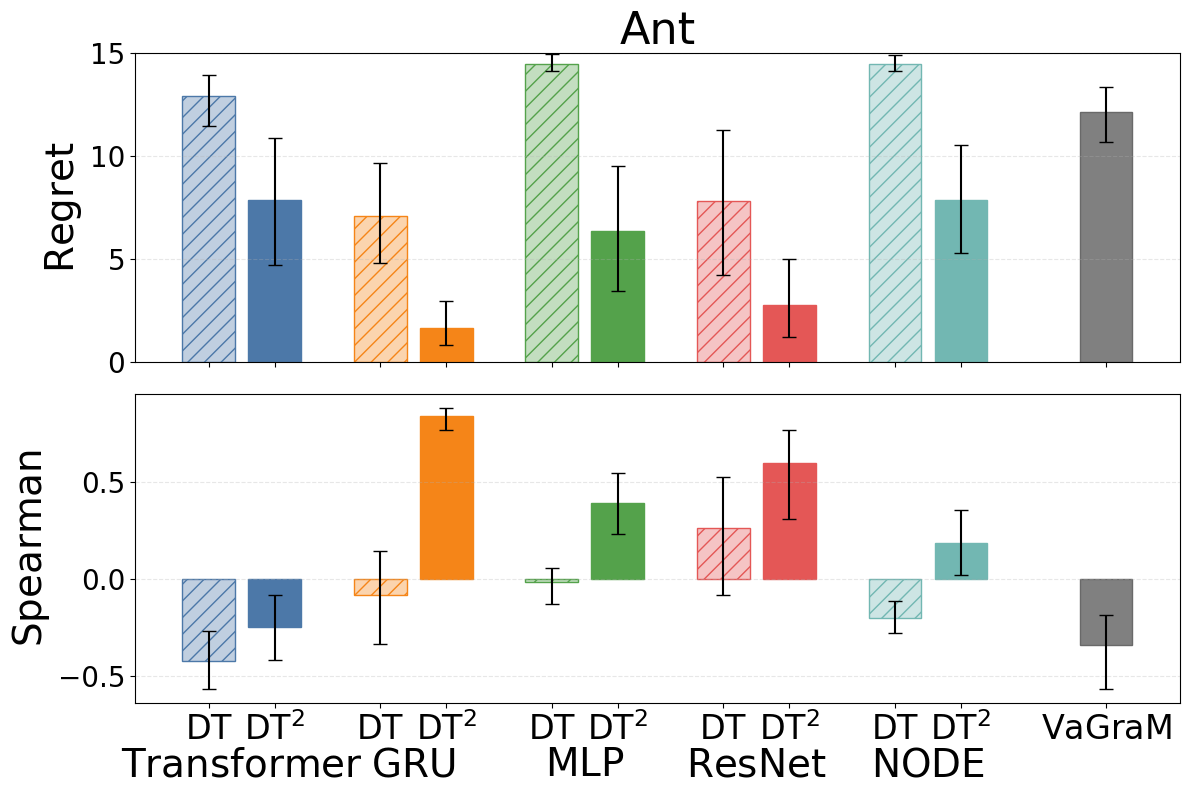

In [2]:
plot_benchmarks(pipeline = 'ant_pipeline', seeds = list(range(0, 10)), ylim = 15, save = True) #lambda 0.1, rollout len 50

In [1]:
#graphing pane
import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats

# ============== CONFIGURATION ==============
PIPELINE = "pendulum_pipeline"  # Change this to switch pipelines (e.g., "lunarlander_pipeline", "cancer_pipeline")
SEEDS = list(range(0, 10))
# ===========================================

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

# VaGraM metric path for VAML files
VAGRAM_METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "VaGraM": ["dynamics", "value_aware"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def process_single_seed_vagram(file_path):
    """Parses a single VAML JSON file and calculates rankings and regrets for VaGraM."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in VAGRAM_METRIC_PATHS.keys()}
    for entry in results:
        for method, path in VAGRAM_METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results_MSE(seed_range, folder, pipeline=PIPELINE):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./test/{pipeline}/{folder}/summary_MSE_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
    return agg_rankings, agg_regrets, valid_seeds

def aggregate_results_vagram(seed_range, pipeline=PIPELINE):
    """Iterates over seeds for resnet folder, processes VAML files, and aggregates VaGraM results."""
    pattern = f"./test/{pipeline}/mlp/summary_VAML_{{}}.json"
    agg_rankings = {m: [] for m in VAGRAM_METRIC_PATHS.keys()}
    agg_regrets = {"VaGraM": []}
    valid_seeds = []
    print(f"Processing VaGraM (VAML) seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed_vagram(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        agg_regrets["VaGraM"].append(single_res["regrets"]["VaGraM"])
    return agg_rankings, agg_regrets, valid_seeds

def collect_performance_bca(rankings, regrets, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    methods = ["supervised", "kendall"]
    for method in methods:
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

def collect_performance_bca_vagram(rankings, regrets, n_boot=10000):
    """Collect BCA stats for VaGraM method."""
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    method = "VaGraM"
    
    if method not in regrets or len(regrets[method]) == 0:
        return results
    
    reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
    spearman_scores = []
    pass1_scores = []
    for true_sort, method_sort in zip(true_rankings, rankings[method]):
        r_true = to_rank_vector(true_sort)
        r_method = to_rank_vector(method_sort)
        corr, _ = stats.spearmanr(r_true, r_method)
        spearman_scores.append(corr)
        pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
    corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
    p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
    results[method] = {
        "regret": (reg_mean, reg_ci),
        "spearman": (corr_mean, corr_ci),
        "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
    }
    return results

# Compute and plot for each model folder

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

def plot_benchmarks_mse(pipeline = PIPELINE, seeds = SEEDS, ylim = 1.5, save=False):
    MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
    metrics = [("regret", r"$\mathrm{Regret}$"), ("spearman", r"$\mathrm{Spearman}$")]

    results_by_folder = {}
    for folder in MODEL_FOLDERS:
        rankings, regrets, processed_seeds = aggregate_results_MSE(seeds, folder, pipeline)
        if not processed_seeds:
            print(f"No valid seeds for {folder}; skipping.")
            continue
        results_by_folder[folder] = collect_performance_bca(rankings, regrets)

    # Aggregate VaGraM results from resnet/summary_VAML_* files
    vagram_rankings, vagram_regrets, vagram_seeds = aggregate_results_vagram(seeds, pipeline)
    vagram_results = collect_performance_bca_vagram(vagram_rankings, vagram_regrets)

    methods = ["supervised", "kendall"]  # Methods per architecture group
    folders = list(results_by_folder.keys())

    # Helper to map folder names to Capitalized + TeX versions
    def format_folder_name(name):
        # Just simple capitalization or specific overrides if needed
        if name.lower() == "gru":
            return r"$\mathrm{GRU}$"
        if name.lower() == "mlp":
            return r"$\mathrm{MLP}$"
        if name.lower() == "ode":
            return r"$\mathrm{NODE}$"
        # For others like Transformer, ResNet, just Title case
        formatted = name.replace("resnet", "ResNet").capitalize()
        if name.lower() == "resnet": formatted = "ResNet"
        return rf"$\mathrm{{{formatted}}}$"

    if not folders:
        print("No results to plot.")
    else:
        group_gap = 0.6
        group_size = len(methods)  # 2 bars per architecture group
        
        # Positions for architecture groups
        positions = []
        for i, folder in enumerate(folders):
            base = i * (group_size + group_gap)
            for j in range(group_size):
                positions.append(base + j)
        centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
        
        # Position for VaGraM bar (rightmost, with extra gap)
        vagram_gap = 1.2  # Extra gap before VaGraM
        vagram_position = positions[-1] + vagram_gap + 1
        
        palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA7"]
        folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
        hatch_map = {"supervised": "//", "kendall": None}
        
        face_colors = []
        edge_colors = []
        hatches = []
        for folder in folders:
            base_color = folder_colors[folder]
            for m in methods:
                if m == "supervised":
                    face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                    edge_colors.append(base_color)
                    hatches.append(hatch_map[m])
                else:
                    face_colors.append(base_color)
                    edge_colors.append(base_color)
                    hatches.append(hatch_map[m])

        fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(max(8, 2 * len(folders) + 2), 8), sharex=True)
        # Format pipeline name for title (e.g., "pendulum_pipeline" -> "Pendulum")
        plot_title = pipeline.replace("_pipeline", "").replace("_", " ").title()
        axes[0].set_title(plot_title, fontsize=32)

        for ax, (metric, label) in zip(axes, metrics):
            means = []
            lowers = []
            uppers = []
            # Architecture group bars
            for folder in folders:
                res = results_by_folder[folder]
                for m in methods:
                    if m not in res:
                        means.append(np.nan)
                        lowers.append(np.nan)
                        uppers.append(np.nan)
                        continue
                    mean, ci = res[m][metric]
                    means.append(mean)
                    lowers.append(mean - ci[0])
                    uppers.append(ci[1] - mean)
            
            # Plot architecture bars
            for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
                ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1, rasterized=True)
            
            # Plot VaGraM bar (grey, standalone)
            if "VaGraM" in vagram_results:
                vagram_mean, vagram_ci = vagram_results["VaGraM"][metric]
                vagram_lo = vagram_mean - vagram_ci[0]
                vagram_up = vagram_ci[1] - vagram_mean
                ax.bar(vagram_position, vagram_mean, yerr=[[vagram_lo], [vagram_up]], capsize=5, 
                    color="grey", edgecolor="dimgrey", linewidth=1, rasterized=True)
            
            ax.set_ylabel(label, fontsize=28)
            ax.grid(axis="y", linestyle="--", alpha=0.3)
            ax.tick_params(axis='y', labelsize=20)
            if metric == "regret":
                ax.set_ylim(0, ylim)

        # Level 1 tick labels: DT (supervised) / DT^2 (kendall) for architecture groups, VaGraM for baseline
        bar_labels = []
        for _ in folders:
            bar_labels.extend([r"$\mathrm{DT}$", r"$\mathrm{DT}^2$"])
        bar_labels.append(r"$\mathrm{VaGraM}$")
        
        all_positions = positions + [vagram_position]
        axes[-1].set_xticks(all_positions)
        axes[-1].set_xticklabels(bar_labels, rotation=0, ha="center", fontsize=24)

        # Level 2 labels: architecture names below the axis
        trans = axes[-1].get_xaxis_transform()
        for center, folder in zip(centers, folders):
            display_name = format_folder_name(folder)
            axes[-1].text(center, -0.14, display_name, transform=trans, ha="center", va="top", fontsize=28)

        folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=format_folder_name(f)) for f in folders]
        method_handles = [
            Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
            Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
            Patch(facecolor="grey", edgecolor="dimgrey", label="VaGraM", linewidth=1),
        ]
        
        fig.tight_layout()
        if save:
            plt.savefig(f'plots/{pipeline}.pdf')

Processing transformer seeds [0, 1, 2, 3]...


Processing gru seeds [0, 1, 2, 3]...
Processing mlp seeds [0, 1, 2, 3]...
Processing resnet seeds [0, 1, 2, 3]...
Processing ode seeds [0, 1, 2, 3]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3]...


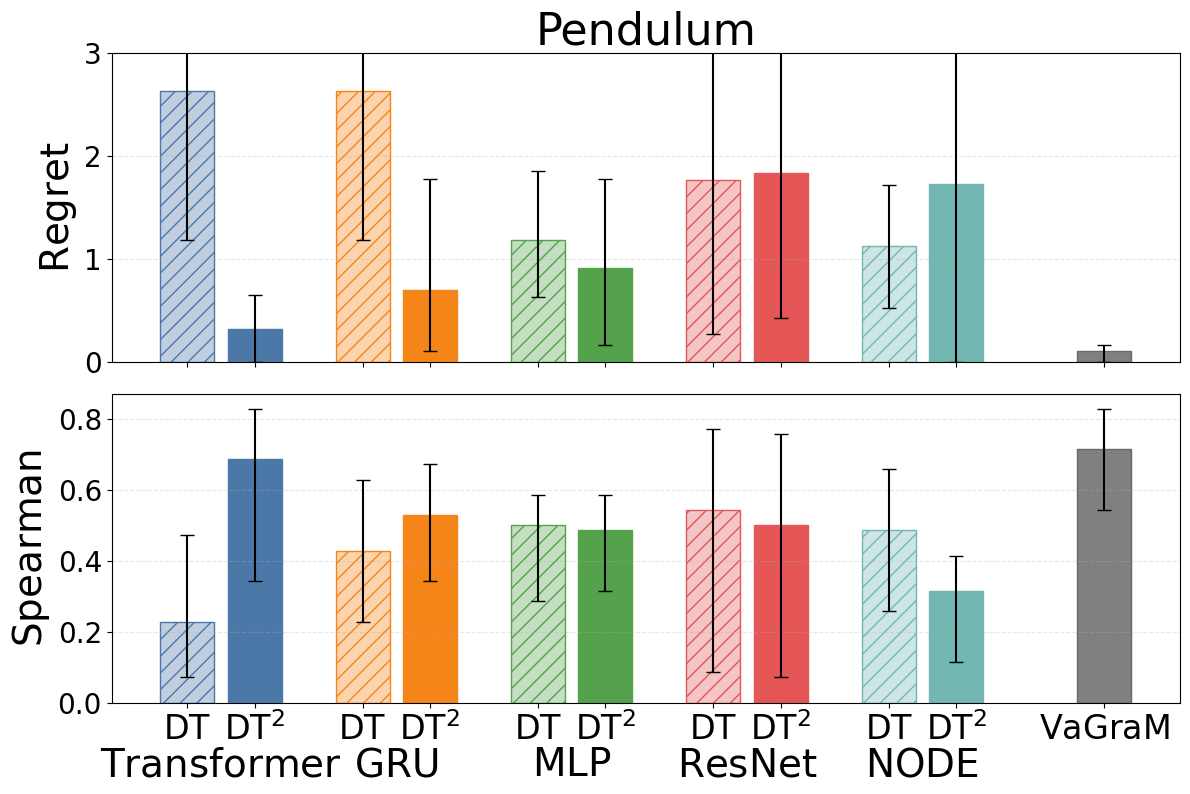

In [2]:
plot_benchmarks_mse(pipeline = 'pendulum_pipeline', seeds = list(range(0,4)), ylim = 3, save = False)

Processing transformer seeds [0, 1, 2, 3]...
Processing gru seeds [0, 1, 2, 3]...
Processing mlp seeds [0, 1, 2, 3]...
Processing resnet seeds [0, 1, 2, 3]...
Processing ode seeds [0, 1, 2, 3]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3]...


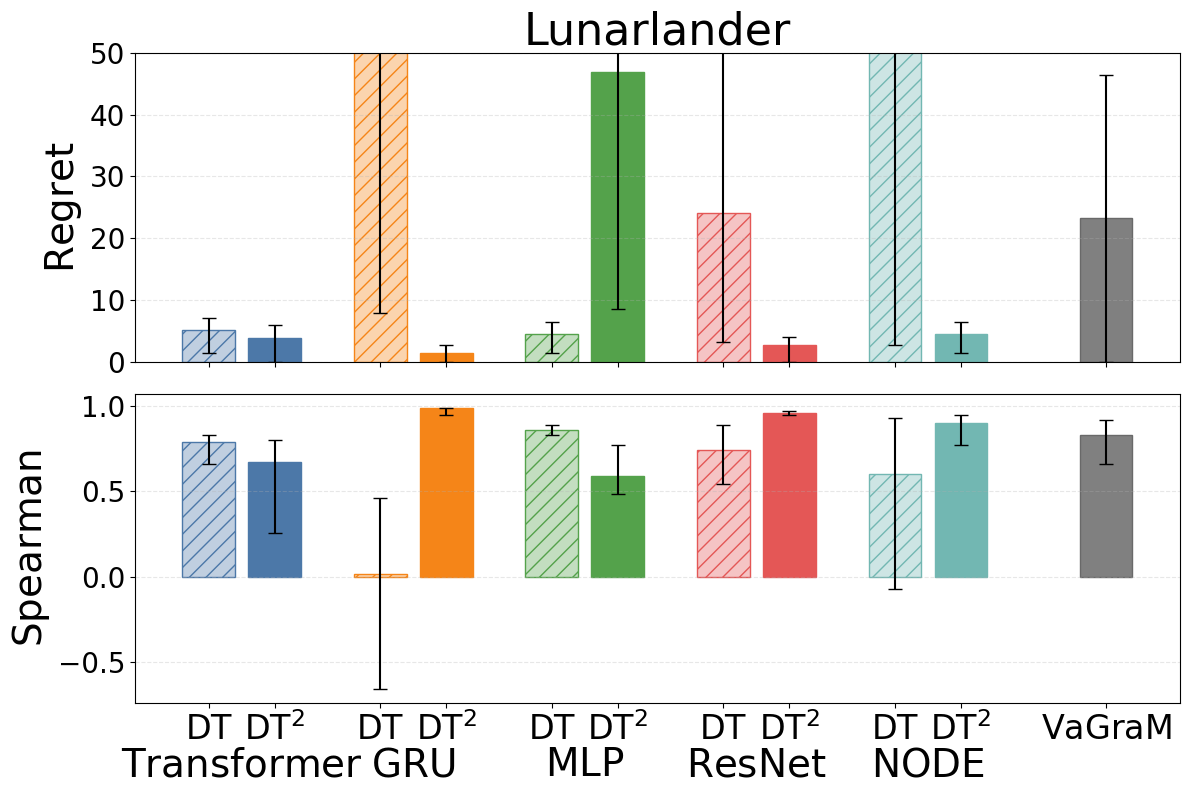

In [3]:
plot_benchmarks_mse(pipeline = 'lunarlander_pipeline', seeds = list(range(0,4)), ylim = 50, save = False)

Processing transformer seeds [0, 1, 2, 3]...


Processing gru seeds [0, 1, 2, 3]...
Processing mlp seeds [0, 1, 2, 3]...
Processing resnet seeds [0, 1, 2, 3]...
Processing ode seeds [0, 1, 2, 3]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3]...


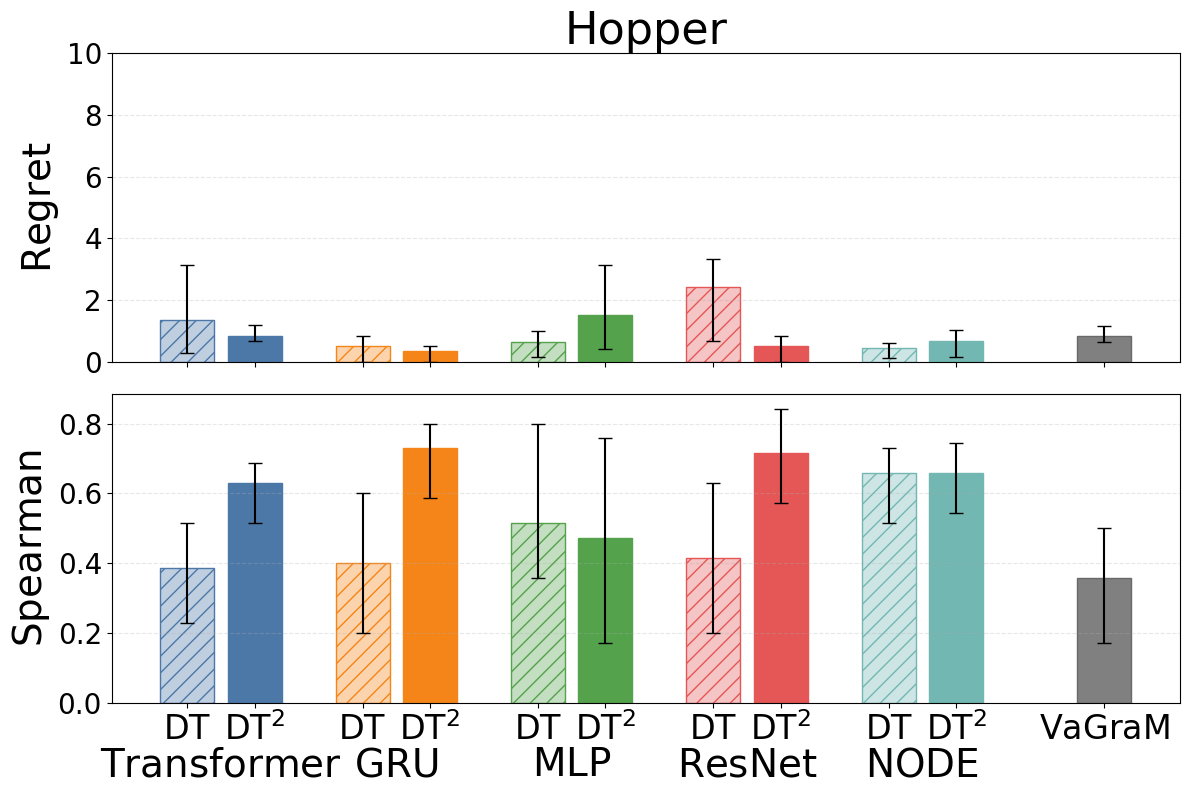

In [4]:
plot_benchmarks_mse(pipeline = 'hopper_pipeline', seeds = list(range(0,4)), ylim = 10, save = False)

Processing transformer seeds [0, 1, 2, 3]...
Processing gru seeds [0, 1, 2, 3]...
Processing mlp seeds [0, 1, 2, 3]...
Processing resnet seeds [0, 1, 2, 3]...
Processing ode seeds [0, 1, 2, 3]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3]...


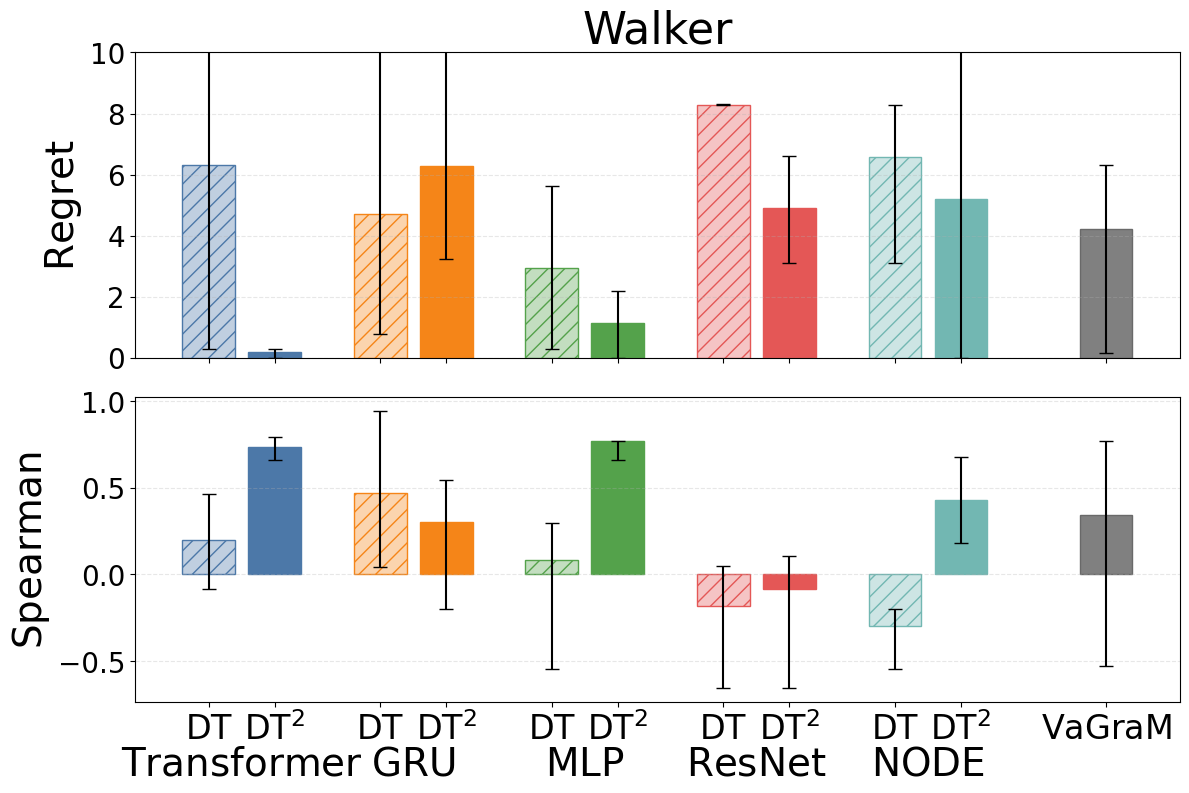

In [5]:
plot_benchmarks_mse(pipeline = 'walker_pipeline', seeds = list(range(0,4)), ylim = 10, save = False)

Processing transformer seeds [0, 1, 2, 3]...
Processing gru seeds [0, 1, 2, 3]...
Processing mlp seeds [0, 1, 2, 3]...
Processing resnet seeds [0, 1, 2, 3]...
Processing ode seeds [0, 1, 2, 3]...
Processing VaGraM (VAML) seeds [0, 1, 2, 3]...


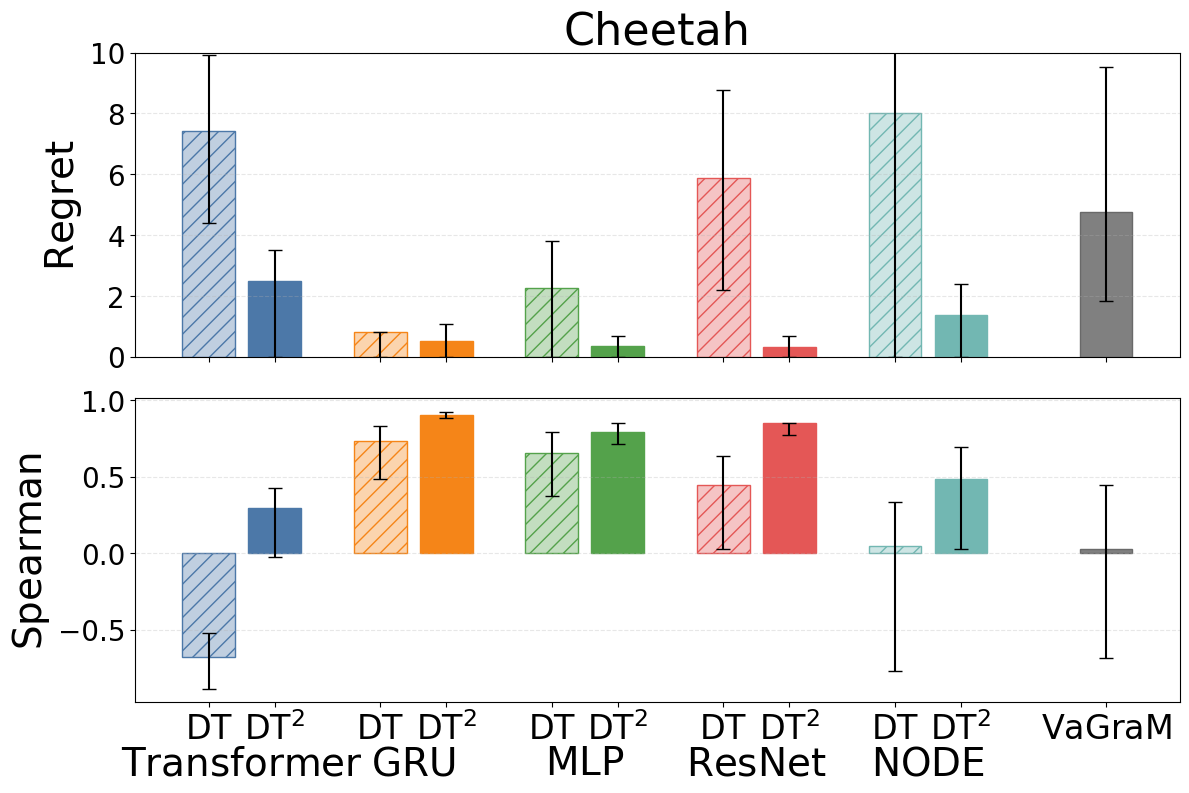

In [6]:
plot_benchmarks_mse(pipeline = 'cheetah_pipeline', seeds = list(range(0,4)), ylim = 10, save = False)

Processing transformer seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...


Processing gru seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing mlp seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing resnet seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing ode seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...


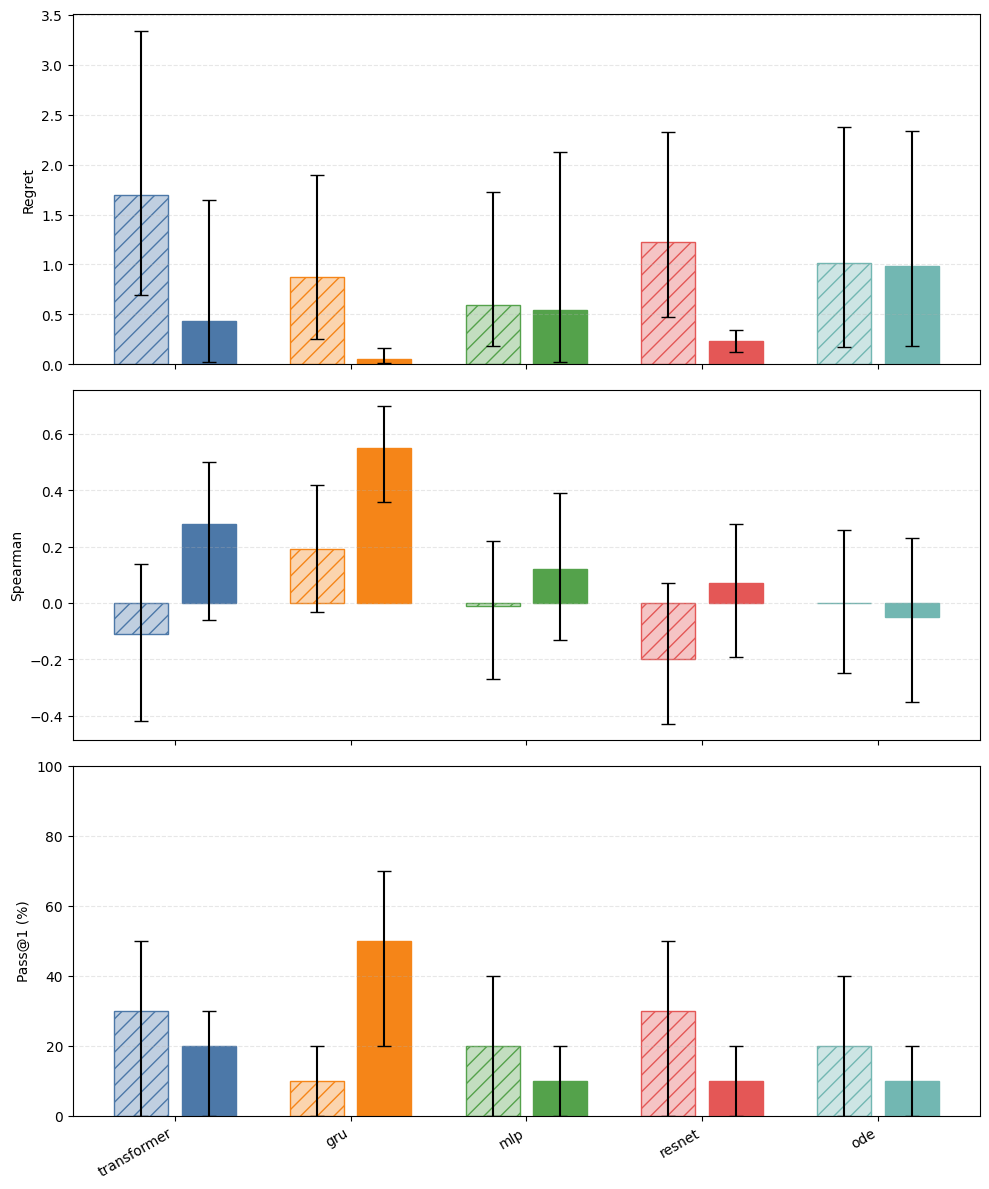

In [17]:
#graphing pane - PENDULUM MSE

import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])[1:]
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results(seed_range, folder):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./test/pendulum_pipeline/{folder}/summary_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
    return agg_rankings, agg_regrets, valid_seeds

SEEDS = list(range(1000, 1010))

def collect_performance_bca(rankings, regrets, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    methods = ["supervised", "kendall"]
    for method in methods:
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

# Compute and plot for each model folder
MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
metrics = [("regret", "Regret"), ("spearman", "Spearman"), ("pass1", "Pass@1 (%)")]

results_by_folder = {}
for folder in MODEL_FOLDERS:
    rankings, regrets, processed_seeds = aggregate_results(SEEDS, folder)
    if not processed_seeds:
        print(f"No valid seeds for {folder}; skipping.")
        continue
    results_by_folder[folder] = collect_performance_bca(rankings, regrets)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

methods = ["supervised", "kendall"]
folders = list(results_by_folder.keys())

if not folders:
    print("No results to plot.")
else:
    group_gap = 0.6
    group_size = len(methods)
    positions = []
    for i, folder in enumerate(folders):
        base = i * (group_size + group_gap)
        for j in range(group_size):
            positions.append(base + j)
    centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
    palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA7"]
    folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
    hatch_map = {"supervised": "//", "kendall": None}
    face_colors = []
    edge_colors = []
    hatches = []
    for folder in folders:
        base_color = folder_colors[folder]
        for m in methods:
            if m == "supervised":
                face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])
            else:
                face_colors.append(base_color)
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(max(8, 2 * len(folders)), 12), sharex=True)

    for ax, (metric, label) in zip(axes, metrics):
        means = []
        lowers = []
        uppers = []
        for folder in folders:
            res = results_by_folder[folder]
            for m in methods:
                if m not in res:
                    means.append(np.nan)
                    lowers.append(np.nan)
                    uppers.append(np.nan)
                    continue
                mean, ci = res[m][metric]
                means.append(mean)
                lowers.append(mean - ci[0])
                uppers.append(ci[1] - mean)
        for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
            ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1)
        ax.set_ylabel(label)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        if metric == "pass1":
            ax.set_ylim(0, 100)

    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(folders, rotation=30, ha="right")

    folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=f) for f in folders]
    method_handles = [
        Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
        Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
    ]

    fig.tight_layout()
    plt.show()

Processing transformer seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...


Processing gru seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing mlp seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing resnet seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing ode seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...


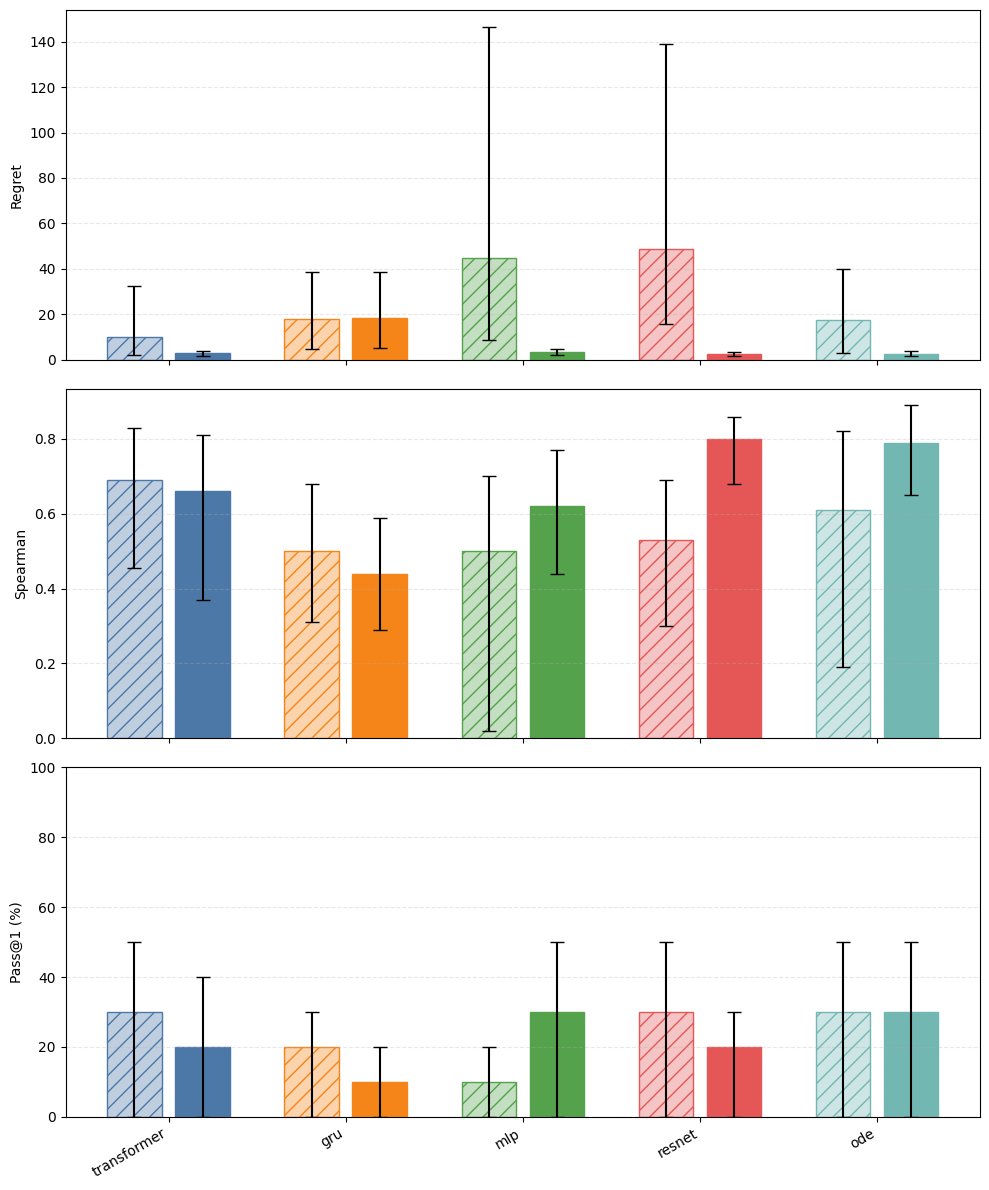

In [15]:
#graphing pane - LUNARLANDER MSE

import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])[1:]
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results(seed_range, folder):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./nll/lunarlander_pipeline/{folder}/summary_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
    return agg_rankings, agg_regrets, valid_seeds

SEEDS = list(range(1000, 1010))

def collect_performance_bca(rankings, regrets, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    methods = ["supervised", "kendall"]
    for method in methods:
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

# Compute and plot for each model folder
MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
metrics = [("regret", "Regret"), ("spearman", "Spearman"), ("pass1", "Pass@1 (%)")]

results_by_folder = {}
for folder in MODEL_FOLDERS:
    rankings, regrets, processed_seeds = aggregate_results(SEEDS, folder)
    if not processed_seeds:
        print(f"No valid seeds for {folder}; skipping.")
        continue
    results_by_folder[folder] = collect_performance_bca(rankings, regrets)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

methods = ["supervised", "kendall"]
folders = list(results_by_folder.keys())

if not folders:
    print("No results to plot.")
else:
    group_gap = 0.6
    group_size = len(methods)
    positions = []
    for i, folder in enumerate(folders):
        base = i * (group_size + group_gap)
        for j in range(group_size):
            positions.append(base + j)
    centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
    palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA7"]
    folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
    hatch_map = {"supervised": "//", "kendall": None}
    face_colors = []
    edge_colors = []
    hatches = []
    for folder in folders:
        base_color = folder_colors[folder]
        for m in methods:
            if m == "supervised":
                face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])
            else:
                face_colors.append(base_color)
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(max(8, 2 * len(folders)), 12), sharex=True)

    for ax, (metric, label) in zip(axes, metrics):
        means = []
        lowers = []
        uppers = []
        for folder in folders:
            res = results_by_folder[folder]
            for m in methods:
                if m not in res:
                    means.append(np.nan)
                    lowers.append(np.nan)
                    uppers.append(np.nan)
                    continue
                mean, ci = res[m][metric]
                means.append(mean)
                lowers.append(mean - ci[0])
                uppers.append(ci[1] - mean)
        for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
            ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1)
        ax.set_ylabel(label)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        if metric == "pass1":
            ax.set_ylim(0, 100)

    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(folders, rotation=30, ha="right")

    folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=f) for f in folders]
    method_handles = [
        Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
        Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
    ]

    fig.tight_layout()
    plt.show()

Processing transformer seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...


Processing gru seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing mlp seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing resnet seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing ode seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...


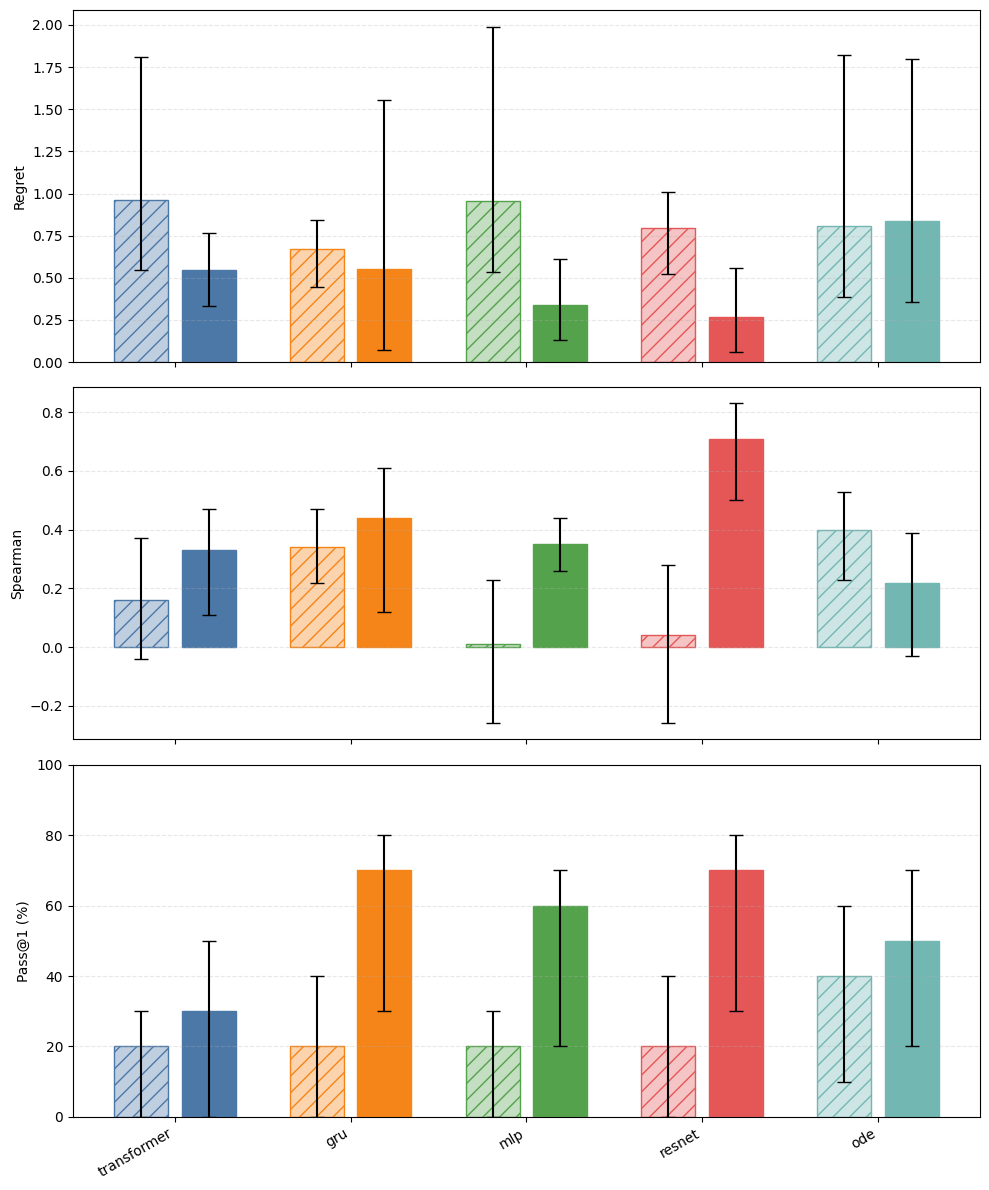

In [9]:
#graphing pane - HOPPER MSE

import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])[1:]
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results(seed_range, folder):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./test/hopper_pipeline/{folder}/summary_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
    return agg_rankings, agg_regrets, valid_seeds

SEEDS = list(range(1000, 1010))

def collect_performance_bca(rankings, regrets, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    methods = ["supervised", "kendall"]
    for method in methods:
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

# Compute and plot for each model folder
MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
metrics = [("regret", "Regret"), ("spearman", "Spearman"), ("pass1", "Pass@1 (%)")]

results_by_folder = {}
for folder in MODEL_FOLDERS:
    rankings, regrets, processed_seeds = aggregate_results(SEEDS, folder)
    if not processed_seeds:
        print(f"No valid seeds for {folder}; skipping.")
        continue
    results_by_folder[folder] = collect_performance_bca(rankings, regrets)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

methods = ["supervised", "kendall"]
folders = list(results_by_folder.keys())

if not folders:
    print("No results to plot.")
else:
    group_gap = 0.6
    group_size = len(methods)
    positions = []
    for i, folder in enumerate(folders):
        base = i * (group_size + group_gap)
        for j in range(group_size):
            positions.append(base + j)
    centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
    palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA7"]
    folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
    hatch_map = {"supervised": "//", "kendall": None}
    face_colors = []
    edge_colors = []
    hatches = []
    for folder in folders:
        base_color = folder_colors[folder]
        for m in methods:
            if m == "supervised":
                face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])
            else:
                face_colors.append(base_color)
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(max(8, 2 * len(folders)), 12), sharex=True)

    for ax, (metric, label) in zip(axes, metrics):
        means = []
        lowers = []
        uppers = []
        for folder in folders:
            res = results_by_folder[folder]
            for m in methods:
                if m not in res:
                    means.append(np.nan)
                    lowers.append(np.nan)
                    uppers.append(np.nan)
                    continue
                mean, ci = res[m][metric]
                means.append(mean)
                lowers.append(mean - ci[0])
                uppers.append(ci[1] - mean)
        for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
            ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1)
        ax.set_ylabel(label)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        if metric == "pass1":
            ax.set_ylim(0, 100)

    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(folders, rotation=30, ha="right")

    folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=f) for f in folders]
    method_handles = [
        Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
        Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
    ]

    fig.tight_layout()
    plt.show()

Processing transformer seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...


Processing gru seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing mlp seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing resnet seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing ode seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...


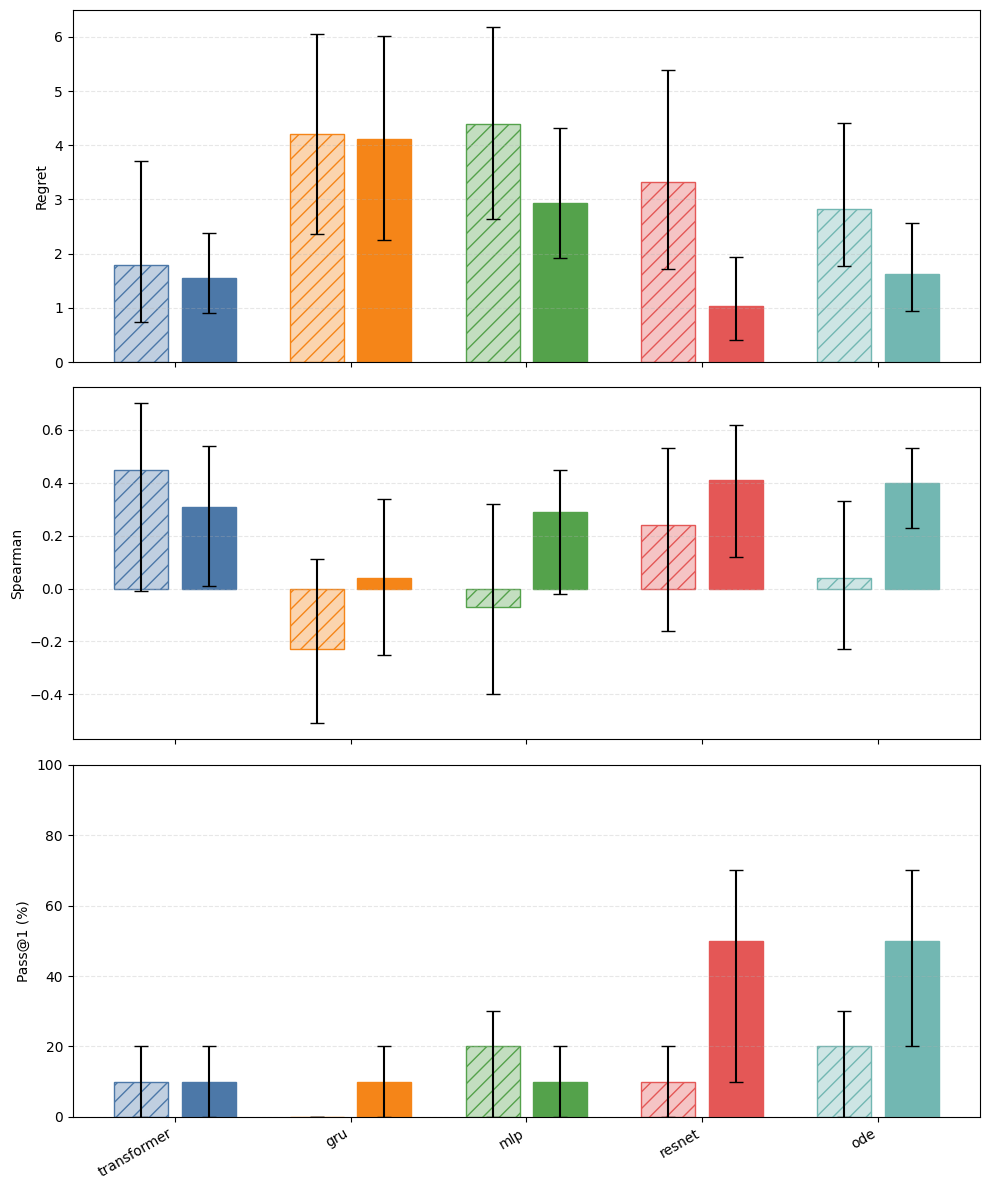

In [11]:
#graphing pane - WALKER MSE

import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])[1:]
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results(seed_range, folder):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./test/walker_pipeline/{folder}/summary_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
    return agg_rankings, agg_regrets, valid_seeds

SEEDS = list(range(1000, 1010))

def collect_performance_bca(rankings, regrets, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    methods = ["supervised", "kendall"]
    for method in methods:
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

# Compute and plot for each model folder
MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
metrics = [("regret", "Regret"), ("spearman", "Spearman"), ("pass1", "Pass@1 (%)")]

results_by_folder = {}
for folder in MODEL_FOLDERS:
    rankings, regrets, processed_seeds = aggregate_results(SEEDS, folder)
    if not processed_seeds:
        print(f"No valid seeds for {folder}; skipping.")
        continue
    results_by_folder[folder] = collect_performance_bca(rankings, regrets)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

methods = ["supervised", "kendall"]
folders = list(results_by_folder.keys())

if not folders:
    print("No results to plot.")
else:
    group_gap = 0.6
    group_size = len(methods)
    positions = []
    for i, folder in enumerate(folders):
        base = i * (group_size + group_gap)
        for j in range(group_size):
            positions.append(base + j)
    centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
    palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA7"]
    folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
    hatch_map = {"supervised": "//", "kendall": None}
    face_colors = []
    edge_colors = []
    hatches = []
    for folder in folders:
        base_color = folder_colors[folder]
        for m in methods:
            if m == "supervised":
                face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])
            else:
                face_colors.append(base_color)
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(max(8, 2 * len(folders)), 12), sharex=True)

    for ax, (metric, label) in zip(axes, metrics):
        means = []
        lowers = []
        uppers = []
        for folder in folders:
            res = results_by_folder[folder]
            for m in methods:
                if m not in res:
                    means.append(np.nan)
                    lowers.append(np.nan)
                    uppers.append(np.nan)
                    continue
                mean, ci = res[m][metric]
                means.append(mean)
                lowers.append(mean - ci[0])
                uppers.append(ci[1] - mean)
        for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
            ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1)
        ax.set_ylabel(label)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        if metric == "pass1":
            ax.set_ylim(0, 100)

    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(folders, rotation=30, ha="right")

    folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=f) for f in folders]
    method_handles = [
        Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
        Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
    ]

    fig.tight_layout()
    plt.show()

Processing transformer seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...


Processing gru seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing mlp seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing resnet seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...
Processing ode seeds [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]...


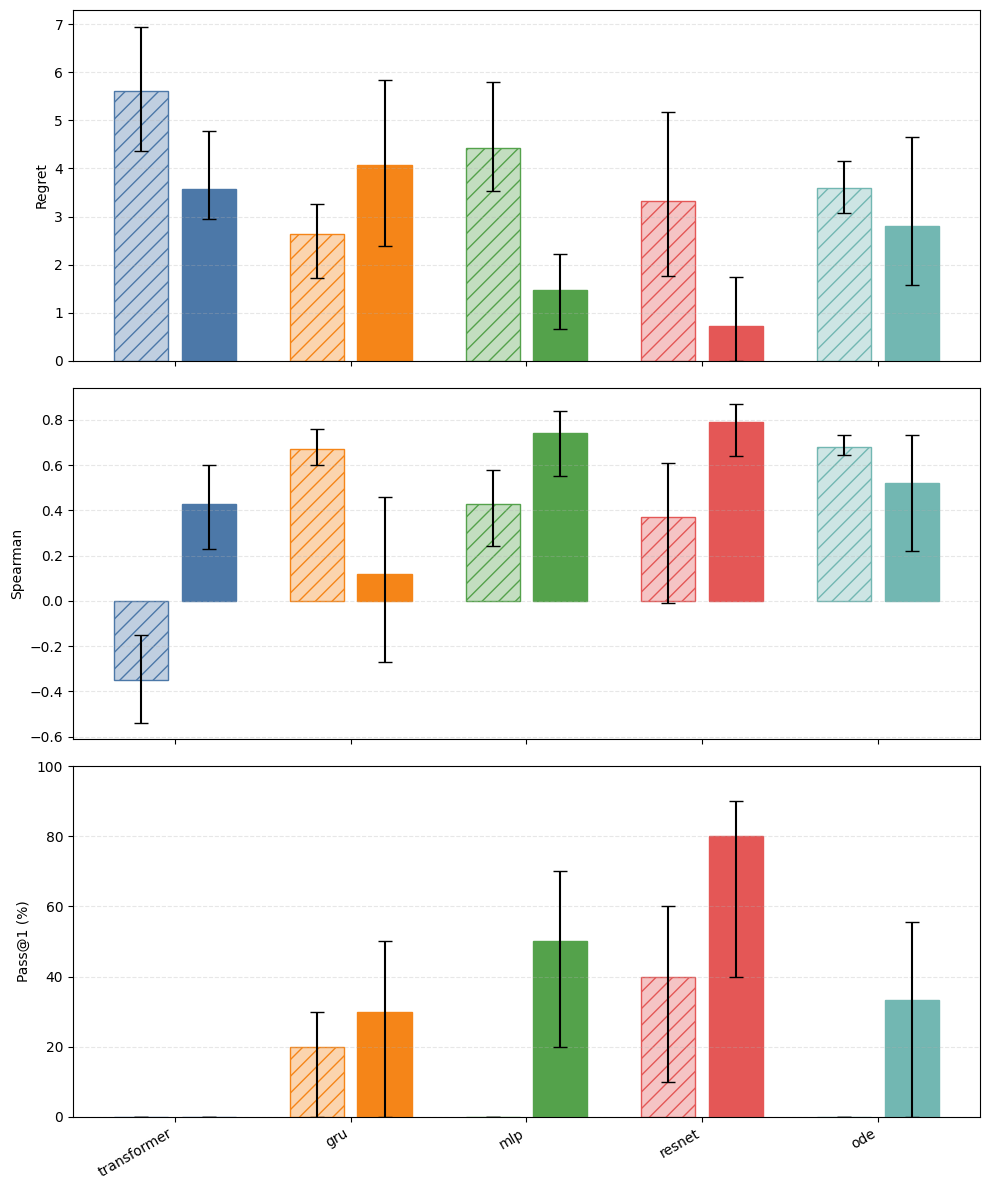

In [13]:
#graphing pane - CHEETAH MSE

import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])[1:]
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results(seed_range, folder):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./test/cheetah_pipeline/{folder}/summary_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
    return agg_rankings, agg_regrets, valid_seeds

SEEDS = list(range(1000, 1010))

def collect_performance_bca(rankings, regrets, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    methods = ["supervised", "kendall"]
    for method in methods:
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

# Compute and plot for each model folder
MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
metrics = [("regret", "Regret"), ("spearman", "Spearman"), ("pass1", "Pass@1 (%)")]

results_by_folder = {}
for folder in MODEL_FOLDERS:
    rankings, regrets, processed_seeds = aggregate_results(SEEDS, folder)
    if not processed_seeds:
        print(f"No valid seeds for {folder}; skipping.")
        continue
    results_by_folder[folder] = collect_performance_bca(rankings, regrets)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

methods = ["supervised", "kendall"]
folders = list(results_by_folder.keys())

if not folders:
    print("No results to plot.")
else:
    group_gap = 0.6
    group_size = len(methods)
    positions = []
    for i, folder in enumerate(folders):
        base = i * (group_size + group_gap)
        for j in range(group_size):
            positions.append(base + j)
    centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
    palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA7"]
    folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
    hatch_map = {"supervised": "//", "kendall": None}
    face_colors = []
    edge_colors = []
    hatches = []
    for folder in folders:
        base_color = folder_colors[folder]
        for m in methods:
            if m == "supervised":
                face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])
            else:
                face_colors.append(base_color)
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(max(8, 2 * len(folders)), 12), sharex=True)

    for ax, (metric, label) in zip(axes, metrics):
        means = []
        lowers = []
        uppers = []
        for folder in folders:
            res = results_by_folder[folder]
            for m in methods:
                if m not in res:
                    means.append(np.nan)
                    lowers.append(np.nan)
                    uppers.append(np.nan)
                    continue
                mean, ci = res[m][metric]
                means.append(mean)
                lowers.append(mean - ci[0])
                uppers.append(ci[1] - mean)
        for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
            ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1)
        ax.set_ylabel(label)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        if metric == "pass1":
            ax.set_ylim(0, 100)

    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(folders, rotation=30, ha="right")

    folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=f) for f in folders]
    method_handles = [
        Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
        Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
    ]

    fig.tight_layout()
    plt.show()

In [258]:
import numpy as np
from scipy import stats

def generate_latex_table(rankings, regrets, env_name="LunarLander (NLL base)"):
    """
    Generates a LaTeX table string with Mean (SE) and bolding for best methods.
    
    Args:
        rankings (dict): Dictionary of lists of lists (rankings).
        regrets (dict): Dictionary of lists of floats (regrets).
        env_name (str): The name of the environment for the first column.
    """
    
    # --- 1. CONFIGURATION & HELPER FUNCTIONS ---
    
    # Map internal keys to nice LaTeX names
    METHOD_NAMES = {
        "supervised": "DT",
        "q_estimate": "FQE",
        "kendall": "$DT^2$",
        "hinge": "Hinge",
        "listnet": "ListNet"
    }
    
    # Define methods list (excluding env_mc)
    methods = [m for m in rankings.keys() if m not in ["env_mc", "q_estimate"]]
    
    # Helper: Get Mean and SE
    def get_stats(data):
        if not data: return 0.0, 0.0
        arr = np.array(data)
        mean = np.mean(arr)
        se = np.std(arr, ddof=1) / np.sqrt(len(arr))
        return mean, se

    # Helper: Convert sorted indices to rank vector (for Spearman)
    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        rank_vec = np.zeros(n)
        for rank, policy_idx in enumerate(sorted_indices):
            rank_vec[policy_idx] = rank
        return rank_vec

    # --- 2. CALCULATE STATISTICS FOR ALL METHODS ---
    
    stats_data = {} # Stores {method: {metric: (mean, se)}}
    true_rankings = rankings.get("env_mc", [])
    num_seeds = len(true_rankings)

    for method in methods:
        method_stats = {}
        
        # A. Regret
        r_mean, r_se = get_stats(regrets[method])
        method_stats['regret'] = (r_mean, r_se)
        
        # B. Spearman & Pass@1
        spearman_scores = []
        pass1_scores = []
        
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            # Spearman
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            
            # Pass@1 (1.0 if match, 0.0 if not)
            is_match = 1.0 if true_sort[0] == method_sort[0] else 0.0
            pass1_scores.append(is_match)
            
        s_mean, s_se = get_stats(spearman_scores)
        method_stats['spearman'] = (s_mean, s_se)
        
        p_mean, p_se = get_stats(pass1_scores)
        # Convert Pass@1 to percentage (0-100) for the table
        method_stats['pass1'] = (p_mean * 100, p_se * 100)
        
        stats_data[method] = method_stats

    # --- 3. IDENTIFY BEST METHODS (FOR BOLDING) ---
    
    metrics = ['spearman', 'pass1', 'regret']
    best_methods = {m: [] for m in metrics} # List of method keys that should be bold

    for metric in metrics:
        # 1. Find the "Outright Best" value
        # Spearman/Pass1 -> Maximize. Regret -> Minimize.
        means = [stats_data[m][metric][0] for m in methods]
        
        if metric == 'regret':
            best_val = min(means)
            best_idx = np.argmin(means)
        else:
            best_val = max(means)
            best_idx = np.argmax(means)
            
        # Get the interval of the outright best: [mean - se, mean + se]
        best_method_key = methods[best_idx]
        best_mean, best_se = stats_data[best_method_key][metric]
        best_interval = (best_mean - best_se, best_mean + best_se)

        # 2. Check Overlap for all other methods
        for method in methods:
            curr_mean, curr_se = stats_data[method][metric]
            curr_interval = (curr_mean - curr_se, curr_mean + curr_se)
            
            # Check intersection
            # Logic: Interval A overlaps Interval B if max(start_A, start_B) <= min(end_A, end_B)
            overlap = max(best_interval[0], curr_interval[0]) <= min(best_interval[1], curr_interval[1])
            
            if overlap:
                best_methods[metric].append(method)

    # --- 4. BUILD LATEX STRING ---
    
    print(r"\begin{table}[th]")
    print(r"    \centering")
    print(f"    \\caption{{Average results over ${num_seeds}$ seeds, reported with standard errors. Best performing methods (overlapping intervals with the outright best) in bold.}}")
    print(r"    \begin{tabular}{c c c c c}")
    print(r"    \toprule")
    print(r"        Environment &  Method & Spearman ($\uparrow$) & Pass@1 \% ($\uparrow$) & Regret@1 ($\downarrow$)\\")
    print(r"    \midrule")
    
    for i, method in enumerate(methods):
        # Determine pretty name
        pretty_name = METHOD_NAMES.get(method, method)
        
        # Prepare row strings
        row_str = ""
        
        # 1. Environment Column (Multirow for first entry)
        if i == 0:
            row_str += f"        \\multirow{{{len(methods)}}}{{*}}{{\\texttt{{{env_name}}}}} & "
        else:
            row_str += "        & "
            
        row_str += f"{pretty_name} & "
        
        # 2. Metrics Columns
        for j, metric in enumerate(['spearman', 'pass1', 'regret']):
            mean, se = stats_data[method][metric]
            
            # Formatting: 2 decimal places usually
            # Special case: Pass@1 might look better with 1 decimal if it's 0-100
            fmt = "{:.2f}"
            if metric == 'pass1': fmt = "{:.1f}" 
            
            val_str = fmt.format(mean)
            se_str = fmt.format(se)
            
            # Apply Bold if in best_methods
            if method in best_methods[metric]:
                cell = f"\\textbf{{{val_str}}}\\,{{\\scriptsize({se_str})}}"
            else:
                cell = f"{val_str}\\,{{\\scriptsize({se_str})}}"
            
            row_str += cell
            if j < 2: row_str += " & "
            
        row_str += "\\\\" # End of row
        print(row_str)

    print(r"    \bottomrule")
    print(r"    \end{tabular}")
    print(r"\end{table}")

# ==========================================
# EXAMPLE USAGE
# ==========================================
if __name__ == "__main__":
    # Assuming 'rankings' and 'regrets' are populated from previous steps
    print("\n--- LATEX TABLE OUTPUT ---\n")
    generate_latex_table(rankings, regrets, env_name="LunarLander (NLL)")


--- LATEX TABLE OUTPUT ---

\begin{table}[th]
    \centering
    \caption{Average results over $9$ seeds, reported with standard errors. Best performing methods (overlapping intervals with the outright best) in bold.}
    \begin{tabular}{c c c c c}
    \toprule
        Environment &  Method & Spearman ($\uparrow$) & Pass@1 \% ($\uparrow$) & Regret@1 ($\downarrow$)\\
    \midrule
        \multirow{4}{*}{\texttt{LunarLander (NLL)}} & DT & \textbf{0.64}\,{\scriptsize(0.06)} & \textbf{22.2}\,{\scriptsize(14.7)} & \textbf{0.27}\,{\scriptsize(0.10)}\\
        & $DT^2$ & \textbf{0.61}\,{\scriptsize(0.14)} & \textbf{44.4}\,{\scriptsize(17.6)} & \textbf{0.76}\,{\scriptsize(0.39)}\\
        & Hinge & \textbf{0.52}\,{\scriptsize(0.13)} & 0.0\,{\scriptsize(0.0)} & \textbf{5.09}\,{\scriptsize(4.92)}\\
        & ListNet & -0.21\,{\scriptsize(0.27)} & 11.1\,{\scriptsize(11.1)} & 20.47\,{\scriptsize(7.75)}\\
    \bottomrule
    \end{tabular}
\end{table}


In [142]:
import json
import os
import numpy as np 

def process_results(folder_path, start_seed, end_seed):
    """
    Iterates through summary files, averages specific metrics, 
    and returns lists of those averages.
    """
    
    # Lists to store the final averages per seed
    avg_supervised_mses = []
    avg_kendall_mses = []
    found_seeds = []

    # print(f"Processing seeds {start_seed} to {end_seed} in '{folder_path}'...")

    for seed in range(start_seed, end_seed + 1):
        filename = f"summary_{seed}.json"
        file_path = os.path.join(folder_path, filename)

        # Check if file exists
        if not os.path.exists(file_path):
            # print(f"  [Warning] File not found: {filename}")
            continue

        try:
            with open(file_path, 'r') as f:
                data = json.load(f)

            # Check if 'results' key exists
            if "results" not in data:
                print(f"  [Warning] No 'results' key in {filename}")
                continue

            results = data["results"]
            
            if not results:
                print(f"  [Warning] 'results' list is empty in {filename}")
                continue

            # Temporary lists to hold values for the current file (current seed)
            file_sup_vals = []
            file_kendall_vals = []

            for entry in results:
                # Access: dynamics -> supervised_mse
                try:
                    s_mse = entry["dynamics"]["supervised_mse"]
                    file_sup_vals.append(s_mse)
                except KeyError:
                    pass 

                # Access: dynamics -> ranking_new_mse -> kendall
                try:
                    k_mse = entry["dynamics"]["ranking_new_mse"]["kendall"]
                    file_kendall_vals.append(k_mse)
                except KeyError:
                    pass

            # Calculate Averages for this file
            if file_sup_vals:
                avg_sup = sum(file_sup_vals) / len(file_sup_vals)
                avg_supervised_mses.append(avg_sup)
            else:
                avg_supervised_mses.append(None) 

            if file_kendall_vals:
                avg_kendall = sum(file_kendall_vals) / len(file_kendall_vals)
                avg_kendall_mses.append(avg_kendall)
            else:
                avg_kendall_mses.append(None)

            found_seeds.append(seed)

        except json.JSONDecodeError:
            print(f"  [Error] Could not decode JSON in {filename}")
        except Exception as e:
            print(f"  [Error] processing {filename}: {e}")

    return found_seeds, avg_supervised_mses, avg_kendall_mses

# ==========================================
# Configuration
# ==========================================
# The base folder containing the method subfolders
BASE_FOLDER = './test/hopper_pipeline' 
METHODS = ['transformer', 'gru', 'ode', 'mlp', 'resnet']

START_SEED = 0
END_SEED = 4

# ==========================================
# Execution
# ==========================================
method_ratios = {}

print("-" * 50)
print(f"Processing Methods: {METHODS}")
print("-" * 50)

for method in METHODS:
    # Construct the full path for the specific method
    method_path = os.path.join(BASE_FOLDER, method)
    
    if not os.path.exists(method_path):
        print(f"Skipping '{method}': Folder not found at {method_path}")
        continue

    # Get the raw lists per seed
    seeds, sup_list, kendall_list = process_results(method_path, START_SEED, END_SEED)
    
    # Filter out None values to calculate valid means
    valid_sup = [x for x in sup_list if x is not None]
    valid_kendall = [x for x in kendall_list if x is not None]

    if not valid_sup or not valid_kendall:
        print(f"Skipping '{method}': No valid data extracted.")
        continue

    # Calculate Grand Averages across all seeds for this method
    mean_sup = np.mean(valid_sup)
    mean_kendall = np.mean(valid_kendall)

    # Calculate Ratio
    if mean_sup == 0:
        ratio = 0.0
        print(f"[Warning] '{method}' has 0 supervised MSE, setting ratio to 0.")
    else:
        ratio = mean_kendall / mean_sup

    method_ratios[method] = ratio
    
    print(f"Method: {method:<15} | Seeds Found: {len(seeds)}")
    print(f"  > Mean Supervised: {mean_sup:.8f}")
    print(f"  > Mean Kendall:    {mean_kendall:.8f}")
    print(f"  > Ratio (K/S):     {ratio:.8f}")
    print("-" * 20)

# ==========================================
# Final Report
# ==========================================
print("\n" + "=" * 50)
print("FINAL RESULTS DICTIONARY")
print("=" * 50)
print(json.dumps(method_ratios, indent=2))

if method_ratios:
    avg_ratio_across_methods = np.mean(list(method_ratios.values()))
    print(f"\nAverage Ratio across all {len(method_ratios)} methods: {avg_ratio_across_methods:.6f}")
else:
    print("\nNo ratios calculated.")

--------------------------------------------------
Processing Methods: ['transformer', 'gru', 'ode', 'mlp', 'resnet']
--------------------------------------------------
Method: transformer     | Seeds Found: 5
  > Mean Supervised: 0.50238248
  > Mean Kendall:    0.32476207
  > Ratio (K/S):     0.64644386
--------------------
Method: gru             | Seeds Found: 3
  > Mean Supervised: 0.05665995
  > Mean Kendall:    0.07548052
  > Ratio (K/S):     1.33216715
--------------------
Method: ode             | Seeds Found: 3
  > Mean Supervised: 0.02465674
  > Mean Kendall:    0.04912396
  > Ratio (K/S):     1.99231380
--------------------
Method: mlp             | Seeds Found: 5
  > Mean Supervised: 0.03627637
  > Mean Kendall:    0.04501980
  > Ratio (K/S):     1.24102262
--------------------
Method: resnet          | Seeds Found: 5
  > Mean Supervised: 0.01575259
  > Mean Kendall:    0.01963386
  > Ratio (K/S):     1.24638928
--------------------

FINAL RESULTS DICTIONARY
{
  "transforme

In [328]:
import json
import os
import numpy as np 
from scipy import stats

def process_results(folder_path, start_seed, end_seed):
    """
    Iterates through summary files, averages specific metrics, 
    and returns lists of those averages.
    """
    
    # Lists to store the final averages per seed
    avg_kendall_mses = []
    found_seeds = []

    for seed in range(start_seed, end_seed + 1):
        filename = f"summary_0.75_{seed}.json"
        file_path = os.path.join(folder_path, filename)

        # Check if file exists
        if not os.path.exists(file_path):
            continue

        try:
            with open(file_path, 'r') as f:
                data = json.load(f)

            # Check if 'results' key exists
            if "results" not in data:
                print(f"  [Warning] No 'results' key in {filename}")
                continue

            results = data["results"]
            
            if not results:
                print(f"  [Warning] 'results' list is empty in {filename}")
                continue

            # Temporary lists to hold values for the current file (current seed)
            file_kendall_vals = []

            for entry in results:
                # Access: dynamics -> ranking_new_mse -> kendall
                try:
                    k_mse = entry["dynamics"]["ranking_new_mse"]["kendall"]
                    file_kendall_vals.append(k_mse)
                except KeyError:
                    pass 

            if file_kendall_vals:
                avg_kendall = sum(file_kendall_vals) / len(file_kendall_vals)
                avg_kendall_mses.append(avg_kendall)
            else:
                avg_kendall_mses.append(None)

            found_seeds.append(seed)

        except json.JSONDecodeError:
            print(f"  [Error] Could not decode JSON in {filename}")
        except Exception as e:
            print(f"  [Error] processing {filename}: {e}")

    return found_seeds, avg_kendall_mses

# ==========================================
# Configuration
# ==========================================
# The base folder containing the method subfolders
BASE_FOLDER = './test/pendulum_pipeline' 
METHODS = ['resnet']

START_SEED = 0
END_SEED = 5

# ==========================================
# Execution
# ==========================================
print("-" * 50)
print(f"Processing Methods: {METHODS}")
print("-" * 50)

for method in METHODS:
    # Construct the full path for the specific method
    method_path = os.path.join(BASE_FOLDER, method)

    if not os.path.exists(method_path):
        print(f"Skipping '{method}': Folder not found at {method_path}")
        continue

    # Get the raw lists per seed
    seeds, kendall_list = process_results(method_path, START_SEED, END_SEED)
    
    # Filter out None values to calculate valid means
    valid_kendall = [x for x in kendall_list if x is not None]

    if not valid_kendall:
        print(f"Skipping '{method}': No valid data extracted.")
        continue

    # Calculate Mean and Standard Error across all seeds for this method
    mean_mse = np.mean(valid_kendall)
    se_mse = stats.sem(valid_kendall) if len(valid_kendall) > 1 else 0.0

    print(f"Method: {method:<15} | Seeds Found: {len(seeds)}")
    print(f"  > Avg MSE:  {mean_mse} ± {se_mse} (S.E.)")
    print("-" * 20)

--------------------------------------------------
Processing Methods: ['resnet']
--------------------------------------------------
Method: resnet          | Seeds Found: 5
  > Avg MSE:  0.0001016393970833936 ± 1.4220032951059808e-05 (S.E.)
--------------------


In [49]:
import json
import os
import numpy as np 

def process_results(folder_path, start_seed, end_seed):
    """
    Iterates through VAML summary files, averages specific metrics, 
    and returns lists of those averages.
    """
    
    # Lists to store the final averages per seed
    avg_vaml_mses = []
    found_seeds = []

    # print(f"Processing seeds {start_seed} to {end_seed} in '{folder_path}'...")

    for seed in range(start_seed, end_seed + 1):
        filename = f"summary_VAML_{seed}.json"
        file_path = os.path.join(folder_path, filename)

        # Check if file exists
        if not os.path.exists(file_path):
            # print(f"  [Warning] File not found: {filename}")
            continue

        try:
            with open(file_path, 'r') as f:
                data = json.load(f)

            # Check if 'results' key exists
            if "results" not in data:
                print(f"  [Warning] No 'results' key in {filename}")
                continue

            results = data["results"]
            
            if not results:
                print(f"  [Warning] 'results' list is empty in {filename}")
                continue

            # Temporary lists to hold values for the current file (current seed)
            file_sup_vals = []
            file_vaml_vals = []

            for entry in results:

                try:
                    v_mse = entry["dynamics"]["value_aware_mse"]
                    file_vaml_vals.append(v_mse)
                except KeyError:
                    pass

            if file_vaml_vals:
                avg_vaml = sum(file_vaml_vals) / len(file_vaml_vals)
                avg_vaml_mses.append(avg_vaml)
            else:
                avg_vaml_mses.append(None)
            found_seeds.append(seed)

        except json.JSONDecodeError:
            print(f"  [Error] Could not decode JSON in {filename}")
        except Exception as e:
            print(f"  [Error] processing {filename}: {e}")

    return found_seeds, avg_vaml_mses

# ==========================================
# Configuration
# ==========================================
# The base folder containing the method subfolders
BASE_FOLDER = './test/pendulum_pipeline' 
METHODS = ['transformer', 'gru', 'ode', 'mlp', 'resnet']

START_SEED = 0
END_SEED = 4

# ==========================================
# Execution
# ==========================================

print("-" * 50)
print(f"Processing Methods: {METHODS}")
print("-" * 50)

for method in METHODS:
    # Construct the full path for the specific method
    method_path = os.path.join(BASE_FOLDER, method)
    
    if not os.path.exists(method_path):
        print(f"Skipping '{method}': Folder not found at {method_path}")
        continue

    # Get the raw lists per seed
    seeds, vaml_list = process_results(method_path, START_SEED, END_SEED)
    
    # Filter out None values to calculate valid means
    valid_vaml = [x for x in vaml_list if x is not None]

    # Calculate Grand Averages across all seeds for this method
    mean_vaml = np.mean(valid_vaml)

    
    print(f"Method: {method:<15} | Seeds Found: {len(seeds)}")
    print(f"  > Mean VAML:    {mean_vaml:.6f}")
    print("-" * 20)

--------------------------------------------------
Processing Methods: ['transformer', 'gru', 'ode', 'mlp', 'resnet']
--------------------------------------------------
Method: transformer     | Seeds Found: 0
  > Mean VAML:    nan
--------------------
Method: gru             | Seeds Found: 0
  > Mean VAML:    nan
--------------------
Method: ode             | Seeds Found: 5
  > Mean VAML:    0.000007
--------------------
Method: mlp             | Seeds Found: 5
  > Mean VAML:    0.000006
--------------------
Method: resnet          | Seeds Found: 5
  > Mean VAML:    0.000021
--------------------


In [35]:
import json
import os
import numpy as np 

def process_results(folder_path, start_seed, end_seed):
    """
    Iterates through summary files, averages specific metrics, 
    and returns lists of those averages per seed.
    """
    
    avg_supervised_mses = []
    avg_kendall_mses = []
    found_seeds = []

    for seed in range(start_seed, end_seed + 1):
        filename = f"summary_{seed}.json"
        file_path = os.path.join(folder_path, filename)

        if not os.path.exists(file_path):
            continue

        try:
            with open(file_path, 'r') as f:
                data = json.load(f)

            if "results" not in data or not data["results"]:
                continue

            results = data["results"][1:]
            
            # Temporary lists for current file
            file_sup_vals = []
            file_kendall_vals = []

            for entry in results:
                # Access: dynamics -> supervised_mse
                try:
                    s_mse = entry["dynamics"]["supervised_mse"]
                    file_sup_vals.append(s_mse)
                except KeyError:
                    pass 

                # Access: dynamics -> ranking_new_mse -> kendall
                try:
                    k_mse = entry["dynamics"]["ranking_new_mse"]["kendall"]
                    file_kendall_vals.append(k_mse)
                except KeyError:
                    pass

            # Calculate Averages for this file (Seed)
            if file_sup_vals:
                avg_sup = sum(file_sup_vals) / len(file_sup_vals)
                avg_supervised_mses.append(avg_sup)
            else:
                avg_supervised_mses.append(None) 

            if file_kendall_vals:
                avg_kendall = sum(file_kendall_vals) / len(file_kendall_vals)
                avg_kendall_mses.append(avg_kendall)
            else:
                avg_kendall_mses.append(None)

            found_seeds.append(seed)

        except Exception as e:
            print(f"  [Error] processing {filename}: {e}")

    return found_seeds, avg_supervised_mses, avg_kendall_mses

# ==========================================
# Configuration
# ==========================================
PIPELINES = [
    './test/cheetah_pipeline', 
    './test/walker_pipeline', 
    './test/hopper_pipeline', 
    './test/pendulum_pipeline', 
    './nll/lunarlander_pipeline',
    './cancer_pipeline'
]

METHODS = ['transformer', 'gru', 'ode', 'mlp', 'resnet']

START_SEED = 1000
END_SEED = 1005

# ==========================================
# Execution
# ==========================================
global_results = {}

print("STARTING PROCESSING...")
print("=" * 60)

for pipeline in PIPELINES:
    print(f"\nProcessing Pipeline: {pipeline}")
    print("-" * 60)
    
    pipeline_ratios = {}
    
    for method in METHODS:
        # Construct path: e.g. ./test/cheetah_pipeline/transformer
        method_path = os.path.join(pipeline, method)
        
        if not os.path.exists(method_path):
            print(f"  [Skipping] '{method}': Folder not found.")
            continue

        # Get raw data
        seeds, sup_list, kendall_list = process_results(method_path, START_SEED, END_SEED)
        
        # Filter Nones
        valid_sup = [x for x in sup_list if x is not None]
        valid_kendall = [x for x in kendall_list if x is not None]

        if not valid_sup or not valid_kendall:
            print(f"  [Skipping] '{method}': No valid data.")
            continue

        # Calculate Means across seeds
        mean_sup = np.mean(valid_sup)
        mean_kendall = np.mean(valid_kendall)

        # Calculate Ratio
        ratio = 0.0
        if mean_sup > 0:
            ratio = mean_kendall / mean_sup
        
        pipeline_ratios[method] = ratio
        
        print(f"  Method: {method:<12} | Seeds: {len(seeds):<2} | Ratio: {ratio:.5f}")

    # Store results for this pipeline
    global_results[pipeline] = pipeline_ratios
    
    # Calculate average ratio for this pipeline (across its methods)
    if pipeline_ratios:
        avg_pipe_ratio = np.mean(list(pipeline_ratios.values()))
        print("-" * 60)
        print(f"  >> Average Ratio for {os.path.basename(pipeline)}: {avg_pipe_ratio:.5f}")
    else:
        print("  >> No data found for this pipeline.")
    
    print("=" * 60)

# ==========================================
# Final Report & Grand Average
# ==========================================
print("\nFINAL SUMMARY DICTIONARY")
print(json.dumps(global_results, indent=2))

print("\nFINAL AVERAGES (Across all methods per pipeline):")
all_collected_ratios = []

for pipe, ratios in global_results.items():
    if ratios:
        # Save for grand total
        all_collected_ratios.extend(ratios.values())
        
        avg = np.mean(list(ratios.values()))
        print(f"{pipe:<30}: {avg:.5f}")
    else:
        print(f"{pipe:<30}: N/A")

# ---------------------------------------------------------
# GRAND AVERAGE CALCULATION
# ---------------------------------------------------------
if all_collected_ratios:
    grand_avg = np.mean(all_collected_ratios)
    print("\n" + "*" * 50)
    print(f"GRAND AVERAGE (Across all {len(all_collected_ratios)} data points): {grand_avg:.5f}")
    print("*" * 50)
else:
    print("\nNo ratios collected to calculate a grand average.")

STARTING PROCESSING...

Processing Pipeline: ./test/cheetah_pipeline
------------------------------------------------------------
  Method: transformer  | Seeds: 6  | Ratio: 0.68912
  Method: gru          | Seeds: 6  | Ratio: 1.15533
  Method: ode          | Seeds: 6  | Ratio: 1.26808
  Method: mlp          | Seeds: 6  | Ratio: 1.14177
  Method: resnet       | Seeds: 6  | Ratio: 1.06976
------------------------------------------------------------
  >> Average Ratio for cheetah_pipeline: 1.06481

Processing Pipeline: ./test/walker_pipeline
------------------------------------------------------------
  Method: transformer  | Seeds: 6  | Ratio: 0.95487
  Method: gru          | Seeds: 6  | Ratio: 1.07106
  Method: ode          | Seeds: 6  | Ratio: 1.18120
  Method: mlp          | Seeds: 6  | Ratio: 0.94179
  Method: resnet       | Seeds: 6  | Ratio: 0.95541
------------------------------------------------------------
  >> Average Ratio for walker_pipeline: 1.02087

Processing Pipeline: ./t

In [49]:
import json
import os
import numpy as np
from scipy import stats

# ==========================================
# CONFIGURATION
# ==========================================
PIPELINES = [
    './test/cheetah_pipeline', 
    './test/walker_pipeline', 
    './test/hopper_pipeline', 
    './test/pendulum_pipeline', 
    './nll/lunarlander_pipeline',
    './test/ant_pipeline'
]

ARCHITECTURES = ['transformer', 'gru', 'ode', 'mlp', 'resnet']

# Only these two metrics
METRIC_PATHS = {
    "supervised": ["dynamics", "supervised"],
    "kendall":    ["dynamics", "ranking_new", "kendall"]
}

GT_KEY = ["env_mc"]

# ==========================================
# GLOBAL AGGREGATORS
# ==========================================
grand_stats = {
    "supervised": {"regrets": [], "correlations": []},
    "kendall":    {"regrets": [], "correlations": []}
}

# ==========================================
# HELPERS
# ==========================================
def get_nested_value(dictionary, keys):
    val = dictionary
    try:
        for key in keys:
            if val is None: return -np.inf
            val = val[key]
        return float(val) if val is not None else -np.inf
    except (KeyError, TypeError, ValueError):
        return -np.inf

def calculate_metrics_for_file(file_path):
    """
    Calculates Regret and Spearman Correlation for a single file.
    """
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except:
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    # 1. Extract Ground Truth
    gt_scores = np.array([get_nested_value(e, GT_KEY) for e in results])

    if np.all(np.isinf(gt_scores)):
        return None
    
    true_optimal_val = np.max(gt_scores)
    file_metrics = {"regrets": {}, "correlations": {}}

    for method_name, json_path in METRIC_PATHS.items():
        # Extract scores for this metric
        method_scores = np.array([get_nested_value(e, json_path) for e in results])

        # --- Regret Calculation (Higher Score = Better Policy) ---
        ranking_indices = np.argsort(method_scores)[::-1]
        selected_idx = ranking_indices[0]
        selected_policy_true_val = gt_scores[selected_idx]

        if np.isinf(selected_policy_true_val):
            regret = np.nan
        else:
            regret = true_optimal_val - selected_policy_true_val
        
        file_metrics["regrets"][method_name] = regret

        # --- Correlation Calculation ---
        if len(method_scores) > 1:
            corr, _ = stats.spearmanr(method_scores, gt_scores)
            file_metrics["correlations"][method_name] = corr if not np.isnan(corr) else 0.0
        else:
            file_metrics["correlations"][method_name] = 0.0

    return file_metrics

# ==========================================
# MAIN EXECUTION
# ==========================================
header = f"{'PIPELINE':<25} | {'ARCH':<12} | {'SUP REG':<9} | {'SUP CORR':<9} | {'KEN REG':<9} | {'KEN CORR':<9} | {'N'}"
print(header)
print("-" * len(header))

for pipeline in PIPELINES:
    pipeline_name = os.path.basename(pipeline)
    
    # -------------------------------------------------
    # DYNAMIC SEED SELECTION
    # -------------------------------------------------
    if 'pendulum' in pipeline_name or 'lunarlander' in pipeline_name:
        current_seeds = list(range(0, 11)) # 0 to 10 inclusive
    elif 'ant' in pipeline_name:
        current_seeds = list(range(5, 8)) 
    else:
        current_seeds = list(range(0, 21)) # 0 to 20 inclusive
    
    for arch in ARCHITECTURES:
        folder_path = os.path.join(pipeline, arch)
        
        if not os.path.exists(folder_path):
            continue

        local_regrets = {"supervised": [], "kendall": []}
        local_corrs   = {"supervised": [], "kendall": []}
        valid_seeds_count = 0

        for seed in current_seeds:
            filename = os.path.join(folder_path, f"summary_{seed}.json")
            if not os.path.exists(filename):
                continue
            
            res = calculate_metrics_for_file(filename)
            if res:
                valid_seeds_count += 1
                for m in METRIC_PATHS:
                    # Store locally for row print
                    local_regrets[m].append(res["regrets"][m])
                    local_corrs[m].append(res["correlations"][m])
                    
                    # Store globally for final report
                    grand_stats[m]["regrets"].append(res["regrets"][m])
                    grand_stats[m]["correlations"].append(res["correlations"][m])

        # --- Print Row ---
        if valid_seeds_count > 0:
            s_reg = np.nanmean(local_regrets["supervised"])
            s_cor = np.nanmean(local_corrs["supervised"])
            k_reg = np.nanmean(local_regrets["kendall"])
            k_cor = np.nanmean(local_corrs["kendall"])
            
            print(f"{pipeline_name:<25} | {arch:<12} | {s_reg:<9.4f} | {s_cor:<9.4f} | {k_reg:<9.4f} | {k_cor:<9.4f} | {valid_seeds_count}")

# ==========================================
# GRAND AVERAGE REPORT
# ==========================================
print("\n" + "=" * 50)
print("GRAND AVERAGES (Across all pipelines & seeds)")
print("=" * 50)

for m in ["supervised", "kendall"]:
    all_regs = grand_stats[m]["regrets"]
    all_corrs = grand_stats[m]["correlations"]
    
    if all_regs:
        avg_reg = np.nanmean(all_regs)
        avg_corr = np.nanmean(all_corrs)
        count = len(all_regs)
        
        print(f"METHOD: {m.upper()}")
        print(f"  > Avg Regret:      {avg_reg:.4f}")
        print(f"  > Avg Correlation: {avg_corr:.4f}")
        print(f"  > Total Data Pts:  {count}")
        print("-" * 30)

PIPELINE                  | ARCH         | SUP REG   | SUP CORR  | KEN REG   | KEN CORR  | N
--------------------------------------------------------------------------------------------
cheetah_pipeline          | transformer  | 4.7441    | 0.0909    | 2.7359    | 0.2883    | 11
cheetah_pipeline          | gru          | 2.7670    | 0.4805    | 1.4436    | 0.5688    | 11
cheetah_pipeline          | ode          | 8.0470    | -0.1371   | 0.6388    | 0.7829    | 10
cheetah_pipeline          | mlp          | 4.5301    | 0.2727    | 1.3566    | 0.7714    | 11


cheetah_pipeline          | resnet       | 5.1135    | 0.4442    | 0.5484    | 0.8961    | 11
walker_pipeline           | transformer  | 3.9710    | 0.4122    | 2.8008    | 0.5551    | 14
walker_pipeline           | gru          | 4.2171    | 0.4694    | 1.8281    | 0.7633    | 14
walker_pipeline           | ode          | 6.0881    | 0.2000    | 0.4651    | 0.8571    | 10
walker_pipeline           | mlp          | 1.9614    | 0.7922    | 0.2096    | 0.9117    | 11
walker_pipeline           | resnet       | 0.5468    | 0.8286    | 0.2482    | 0.8971    | 10
hopper_pipeline           | transformer  | 1.3870    | 0.5381    | 0.6462    | 0.6381    | 12
hopper_pipeline           | gru          | 1.5572    | 0.4000    | 1.0598    | 0.5257    | 10
hopper_pipeline           | ode          | 0.5868    | 0.6444    | 0.9032    | 0.6381    | 9
hopper_pipeline           | mlp          | 1.5526    | 0.3905    | 2.3780    | 0.4048    | 12
hopper_pipeline           | resnet       | 0.7143    | 0.5714

In [3]:
(5.8032 - 1.2067)/ 1.2067 * 100

380.9148918538162

In [4]:
0.7068 / 0.5171

1.366853606652485

In [21]:
0.5128 / 0.3124

1.6414852752880922